# Exploratory Data Analysis — California Wildfire Dataset

Our dataset covers **3,668 grid cells** across California from **2018–2020** (4M rows, 33 features). Fires are rare — only **0.27%** of cell-days have a fire. This EDA investigates which features predict fire, how they relate to each other, and whether any are redundant.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

df = pd.read_parquet('../data/processed/california_dataset.parquet')
print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Fire-days: {df["has_fire"].sum():,} ({df["has_fire"].mean()*100:.3f}%)')
print(f'Date range: {df["date"].min().date()} to {df["date"].max().date()}')
print(f'Grid cells: {df["grid_id"].nunique():,}')

feature_cols = [c for c in df.columns if c not in ['grid_id', 'date', 'has_fire', 'fire_count', 'total_acres']]

df.head(10)

Shape: 4,020,128 rows × 33 columns
Fire-days: 10,960 (0.273%)
Date range: 2018-01-01 to 2020-12-31
Grid cells: 3,668


,grid_id,date,fire_count,total_acres,has_fire,rmin,vs,pr,vpd,fm100,...,tmmx_7d,rmin_7d,dry_streak,pr_7d,pr_14d,fm100_change_3d,vpd_change_3d,month,month_sin,doy_cos
0,73,2018-01-01,0,0.0,0,56.0,1.7,0.0,0.29,19.0,...,16.750000,56.000000,1,0.0,0.0,0.0,0.00,1,0.5,0.999852
1,73,2018-01-02,0,0.0,0,47.1,1.6,0.0,0.49,18.8,...,18.450000,51.550000,2,0.0,0.0,0.0,0.00,1,0.5,0.999407
2,73,2018-01-03,0,0.0,0,57.3,1.6,0.0,0.35,19.1,...,18.616667,53.466667,3,0.0,0.0,0.0,0.00,1,0.5,0.998667
3,73,2018-01-04,0,0.0,0,50.4,2.5,0.0,0.45,19.1,...,19.100000,52.700000,4,0.0,0.0,0.1,0.16,1,0.5,0.997630
4,73,2018-01-05,0,0.0,0,49.6,3.8,0.0,0.59,18.9,...,19.410000,52.080000,5,0.0,0.0,0.1,0.10,1,0.5,0.996298
5,73,2018-01-06,0,0.0,0,59.4,3.3,0.0,0.36,18.4,...,19.266667,53.300000,6,0.0,0.0,-0.7,0.01,1,0.5,0.994671
6,73,2018-01-07,0,0.0,0,58.0,2.1,0.0,0.44,18.0,...,19.164286,53.971429,7,0.0,0.0,-1.1,-0.01,1,0.5,0.992749
7,73,2018-01-08,0,0.0,0,51.6,3.3,13.3,0.69,19.9,...,19.735714,53.342857,0,13.3,13.3,1.0,0.10,1,0.5,0.990532
8,73,2018-01-09,0,0.0,0,54.1,9.3,14.9,0.58,21.2,...,19.478571,54.342857,0,28.2,28.2,2.8,0.22,1,0.5,0.988023
9,73,2018-01-10,0,0.0,0,66.9,2.0,0.3,0.21,20.8,...,19.050000,55.714286,1,28.5,28.5,2.8,-0.23,1,0.5,0.985220


## Feature Reference

| Feature | Description | Source |
|---------|-------------|--------|
| **Weather** *(daily)* | | |
| `tmmx_c` | Max temperature (°C) | gridMET |
| `rmin` | Min relative humidity (%) | gridMET |
| `vs` | Wind speed (m/s) | gridMET |
| `pr` | Precipitation (mm) | gridMET |
| `vpd` | Vapor pressure deficit (kPa) — how dry the air is | gridMET |
| `fm100` | 100-hour fuel moisture (%) — moisture in dead branches | gridMET |
| `bi` | Burning Index — overall fire danger rating | gridMET |
| **Vegetation** *(monthly, forward-filled)* | | |
| `aet` | Actual evapotranspiration (mm) — water plants are using | TerraClimate |
| `water_deficit` | Climatic water deficit (mm) — gap between need and supply | TerraClimate |
| **Lightning** *(daily)* | | |
| `lightning_count` | Lightning/thunderstorm events in this cell | NOAA Storm Events |
| **Rolling Averages** | | |
| `tmmx_7d` | 7-day avg temperature | Derived from gridMET |
| `erc_7d`, `erc_14d` | 7/14-day avg energy release component | Derived |
| `vpd_7d`, `vpd_14d` | 7/14-day avg vapor pressure deficit | Derived |
| `bi_7d`, `bi_14d` | 7/14-day avg burning index | Derived |
| `rmin_7d` | 7-day avg humidity | Derived |
| `pr_7d`, `pr_14d` | 7/14-day cumulative precipitation | Derived |
| **Trends** | | |
| `dry_streak` | Consecutive days without rain | Derived |
| `fm100_change_3d` | 3-day change in fuel moisture | Derived |
| `vpd_change_3d` | 3-day change in VPD | Derived |
| **Temporal** | | |
| `month`, `month_sin`, `doy_cos` | Seasonal cycle encodings | Derived |
| **Location** | | |
| `lat_center`, `lon_center` | Grid cell coordinates | Grid |

---
## 1. Correlation Heatmap
First question: which features move together? A heatmap of all pairwise correlations reveals clusters of redundant features and inverse relationships. Red = positive correlation, blue = negative.

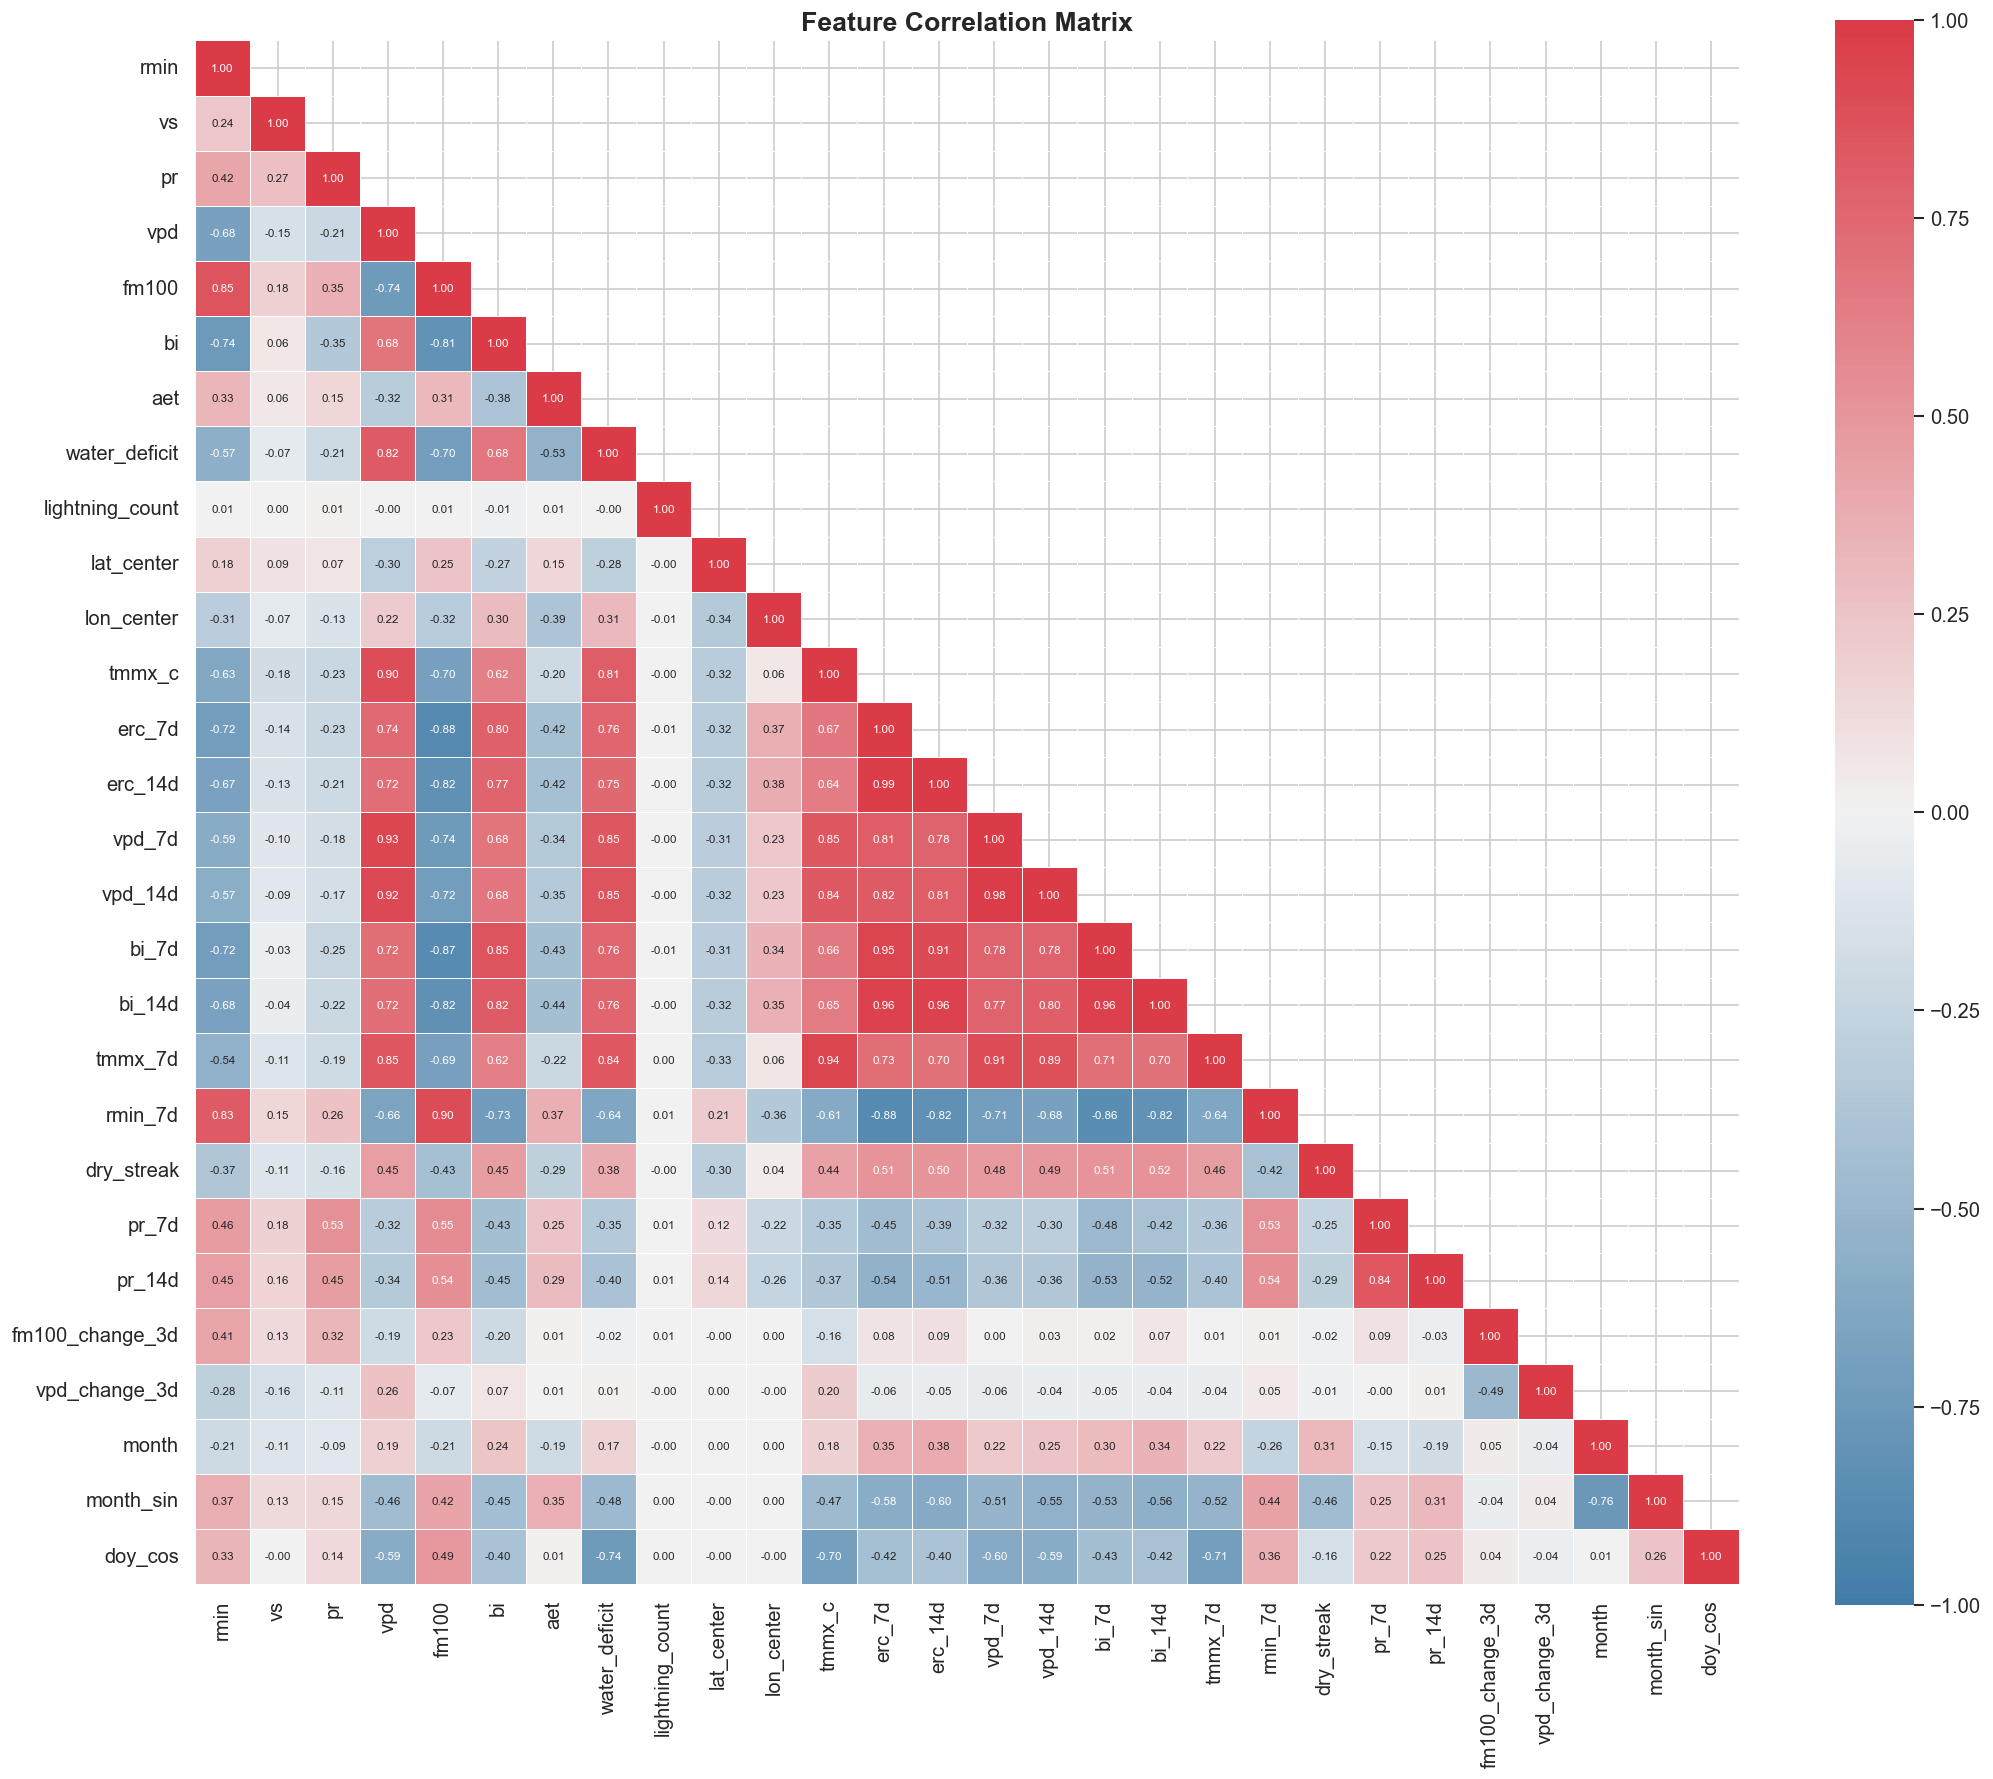

In [2]:
corr = df[feature_cols].corr()

fig, ax = plt.subplots(figsize=(18, 15))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
cmap = sns.diverging_palette(240, 10, as_cmap=True)
sns.heatmap(corr, mask=mask, cmap=cmap, center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', annot_kws={'size': 7},
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Feature Correlation Matrix', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../notebooks/plots/01_correlation_heatmap.png', bbox_inches='tight')
plt.show()

**Takeaways:**
- **Temperature–dryness cluster**: `tmmx_c`, `vpd`, and their rolling averages are tightly linked (r > 0.85). Hot and dry go together.
- **Fire danger cluster**: `erc_7d`, `erc_14d`, `bi_7d`, `bi_14d` form a correlated block (r > 0.93) — they're calculated from similar inputs.
- **Moisture cluster**: `fm100`, `rmin`, `rmin_7d` move together but *inversely* with fire danger — wetter fuels = less fire risk.
- **Precipitation** (`pr`, `pr_7d`, `pr_14d`) is weakly correlated with most features, meaning rain provides independent information.

---
## 2. Feature Correlation with Fire
Now the central question: which features are most associated with fire occurrence? This ranks every feature by its Pearson correlation with `has_fire`. Red = more fire when feature is high, blue = less fire.

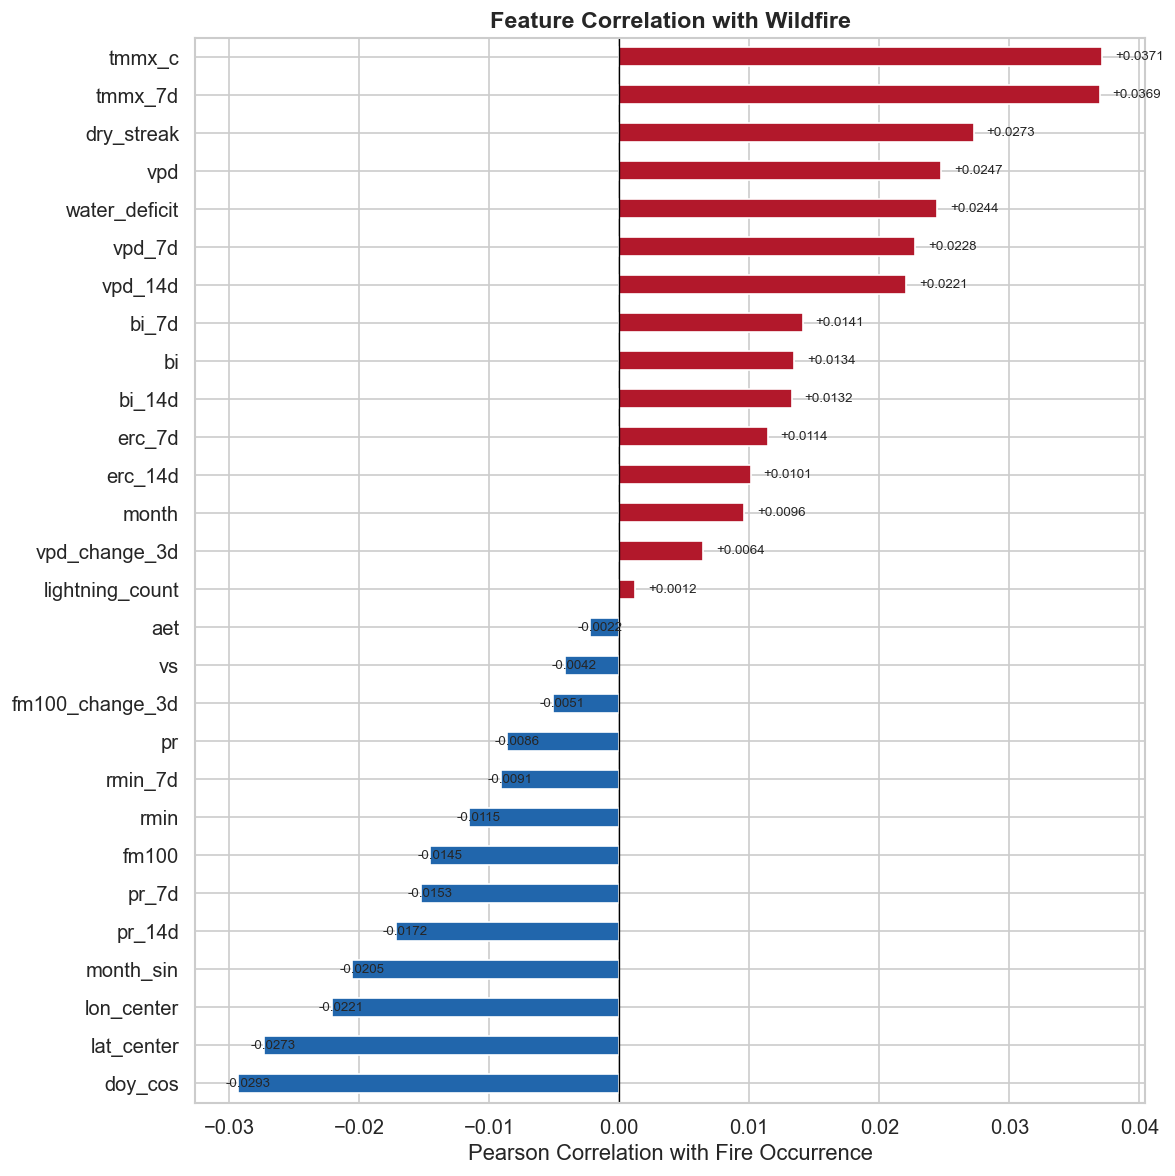

In [3]:
fire_corr = df[feature_cols].corrwith(df['has_fire']).sort_values()

fig, ax = plt.subplots(figsize=(10, 10))
colors = ['#2166ac' if v < 0 else '#b2182b' for v in fire_corr.values]
fire_corr.plot.barh(ax=ax, color=colors)
ax.set_xlabel('Pearson Correlation with Fire Occurrence')
ax.set_title('Feature Correlation with Wildfire', fontsize=14, fontweight='bold')
ax.axvline(x=0, color='black', linewidth=0.8)
for i, (val, name) in enumerate(zip(fire_corr.values, fire_corr.index)):
    ax.text(val + 0.001 * np.sign(val), i, f'{val:+.4f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('../notebooks/plots/02_fire_correlation_ranking.png', bbox_inches='tight')
plt.show()

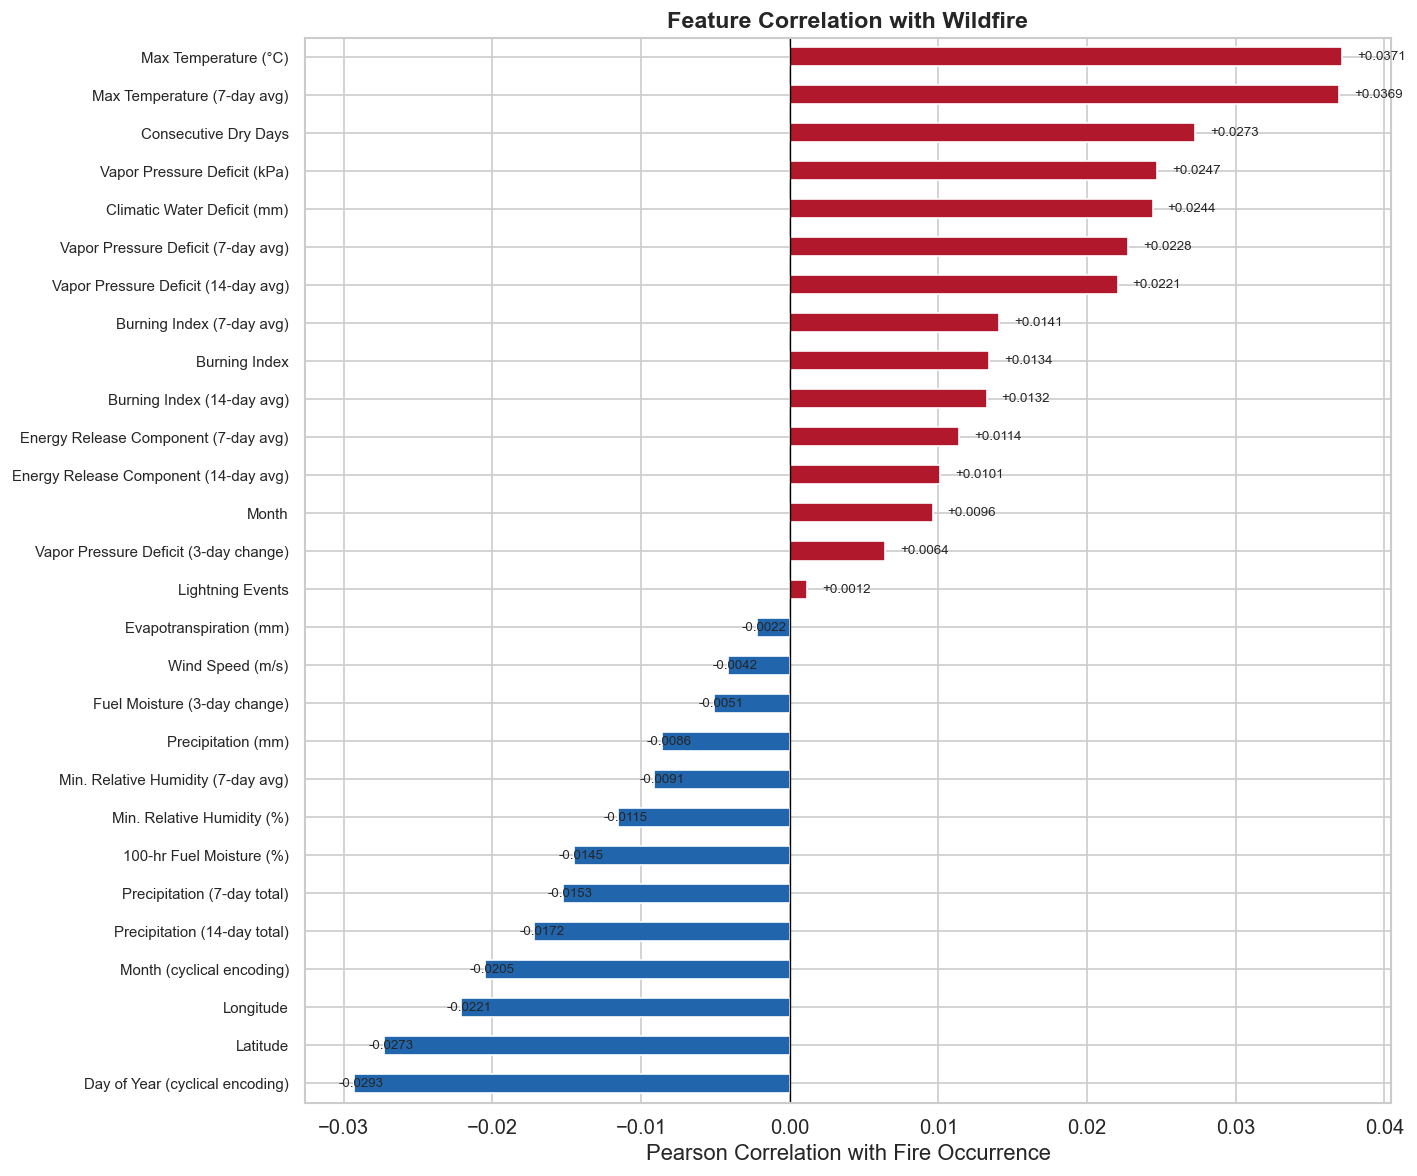

In [4]:
feature_labels = {
    'tmmx_c': 'Max Temperature (°C)',
    'rmin': 'Min. Relative Humidity (%)',
    'vs': 'Wind Speed (m/s)',
    'pr': 'Precipitation (mm)',
    'vpd': 'Vapor Pressure Deficit (kPa)',
    'fm100': '100-hr Fuel Moisture (%)',
    'bi': 'Burning Index',
    'aet': 'Evapotranspiration (mm)',
    'water_deficit': 'Climatic Water Deficit (mm)',
    'lightning_count': 'Lightning Events',
    'lat_center': 'Latitude',
    'lon_center': 'Longitude',
    'erc_7d': 'Energy Release Component (7-day avg)',
    'erc_14d': 'Energy Release Component (14-day avg)',
    'vpd_7d': 'Vapor Pressure Deficit (7-day avg)',
    'vpd_14d': 'Vapor Pressure Deficit (14-day avg)',
    'bi_7d': 'Burning Index (7-day avg)',
    'bi_14d': 'Burning Index (14-day avg)',
    'tmmx_7d': 'Max Temperature (7-day avg)',
    'rmin_7d': 'Min. Relative Humidity (7-day avg)',
    'dry_streak': 'Consecutive Dry Days',
    'pr_7d': 'Precipitation (7-day total)',
    'pr_14d': 'Precipitation (14-day total)',
    'fm100_change_3d': 'Fuel Moisture (3-day change)',
    'vpd_change_3d': 'Vapor Pressure Deficit (3-day change)',
    'month': 'Month',
    'month_sin': 'Month (cyclical encoding)',
    'doy_cos': 'Day of Year (cyclical encoding)',
}

# Same ranking as the chart above, with full feature names for the paper.
fire_corr_labeled = fire_corr.rename(index=feature_labels)

fig, ax = plt.subplots(figsize=(12, 10))
colors = ['#2166ac' if v < 0 else '#b2182b' for v in fire_corr_labeled.values]
fire_corr_labeled.plot.barh(ax=ax, color=colors)
ax.set_xlabel('Pearson Correlation with Fire Occurrence')
ax.set_title('Feature Correlation with Wildfire', fontsize=14, fontweight='bold')
ax.axvline(x=0, color='black', linewidth=0.8)
ax.tick_params(axis='y', labelsize=9)
for i, (val, name) in enumerate(zip(fire_corr_labeled.values, fire_corr_labeled.index)):
    ax.text(val + 0.001 * np.sign(val), i, f'{val:+.4f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('../notebooks/plots/02b_fire_correlation_labeled.png', bbox_inches='tight', dpi=150)
plt.show()

**Takeaways:**
- **Top predictors**: Temperature (`tmmx_c`), dry streak, VPD (air dryness), and water deficit (vegetation dryness) lead.
- **Suppressors**: Recent rain (`pr_14d`), fuel moisture (`fm100`), and humidity (`rmin`) are negatively correlated — they reduce fire risk.
- **All correlations are small** (< 0.04). This is expected for rare events (0.27%). Fires are driven by *combinations* of factors, not any single variable. The model will combine these weak signals.

---
## 3. Fire vs Non-Fire Distributions
Correlation tells us direction, but not *how much* the distributions differ. Box plots compare each feature's spread on fire days vs non-fire days. Good separation = the feature distinguishes the two classes.

/var/folders/s8/px1gshls527_h0fkcl2rr_940000gn/T/ipykernel_83886/3010320262.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='Fire', y=col, ax=ax,
/var/folders/s8/px1gshls527_h0fkcl2rr_940000gn/T/ipykernel_83886/3010320262.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='Fire', y=col, ax=ax,
/var/folders/s8/px1gshls527_h0fkcl2rr_940000gn/T/ipykernel_83886/3010320262.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='Fire', y=col, ax=ax,
/var/folders/s8/px1gshls527_h0fkcl2rr_940000gn

/var/folders/s8/px1gshls527_h0fkcl2rr_940000gn/T/ipykernel_83886/3010320262.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='Fire', y=col, ax=ax,


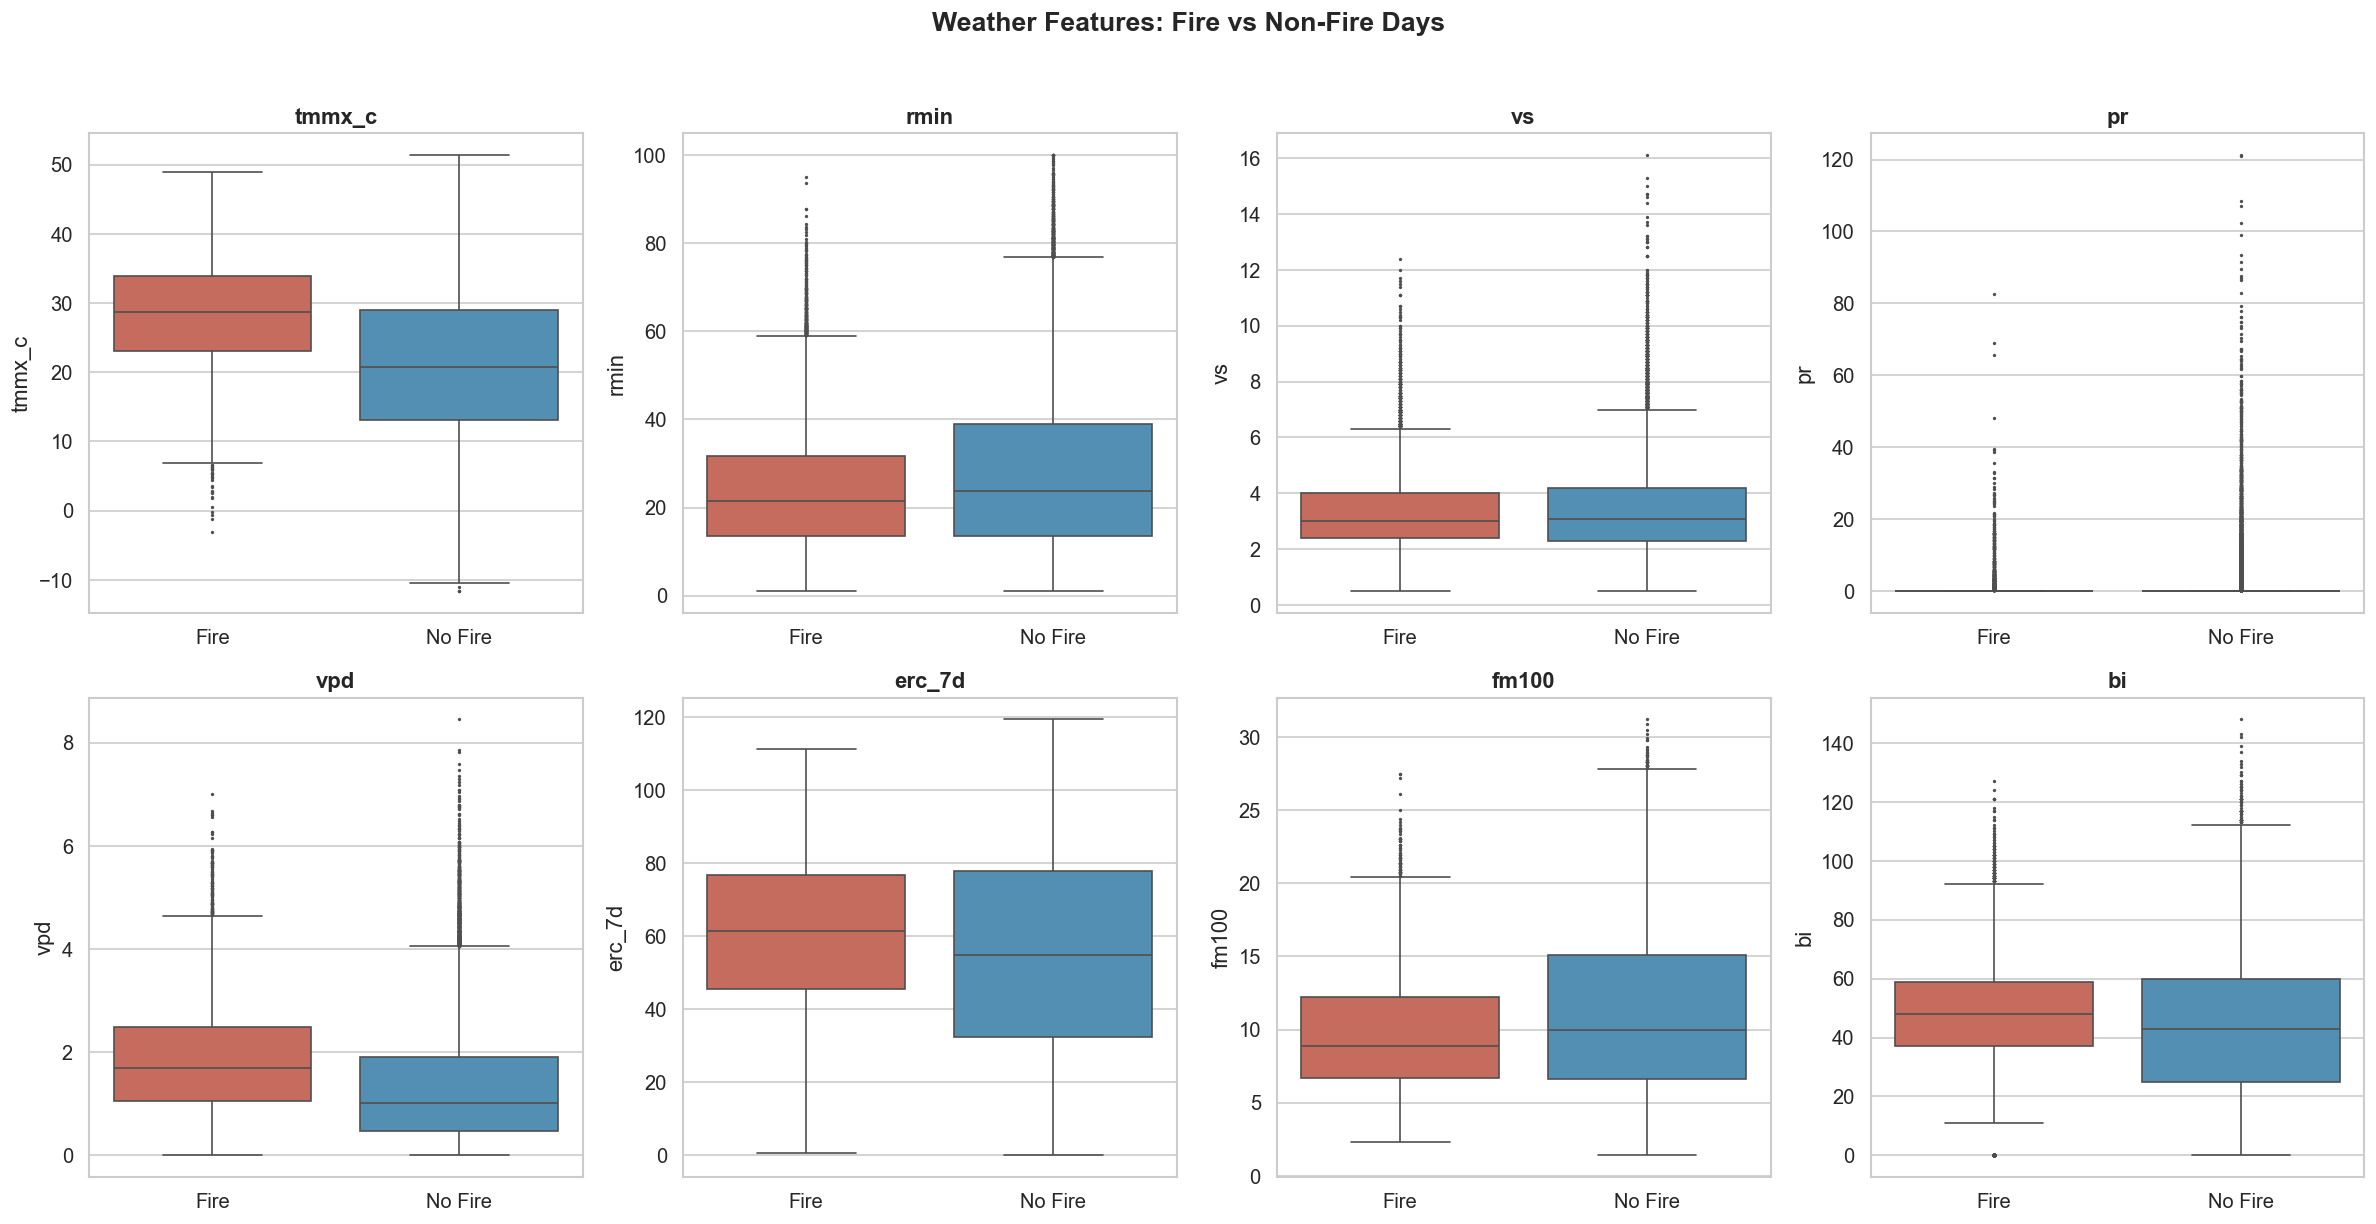

In [5]:
fire_df = df[df['has_fire'] == 1]
nofire_sample = df[df['has_fire'] == 0].sample(n=len(fire_df) * 3, random_state=42)
plot_df = pd.concat([fire_df, nofire_sample])
plot_df['Fire'] = plot_df['has_fire'].map({0: 'No Fire', 1: 'Fire'})

weather_features = ['tmmx_c', 'rmin', 'vs', 'pr', 'vpd', 'erc_7d', 'fm100', 'bi']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for ax, col in zip(axes.ravel(), weather_features):
    sns.boxplot(data=plot_df, x='Fire', y=col, ax=ax, 
                palette={'No Fire': '#4393c3', 'Fire': '#d6604d'},
                fliersize=1)
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('')
fig.suptitle('Weather Features: Fire vs Non-Fire Days', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../notebooks/plots/03_fire_vs_nofire_weather.png', bbox_inches='tight')
plt.show()

/var/folders/s8/px1gshls527_h0fkcl2rr_940000gn/T/ipykernel_83886/2599518826.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='Fire', y=col, ax=ax,
/var/folders/s8/px1gshls527_h0fkcl2rr_940000gn/T/ipykernel_83886/2599518826.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='Fire', y=col, ax=ax,
/var/folders/s8/px1gshls527_h0fkcl2rr_940000gn/T/ipykernel_83886/2599518826.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='Fire', y=col, ax=ax,
/var/folders/s8/px1gshls527_h0fkcl2rr_940000gn/T/

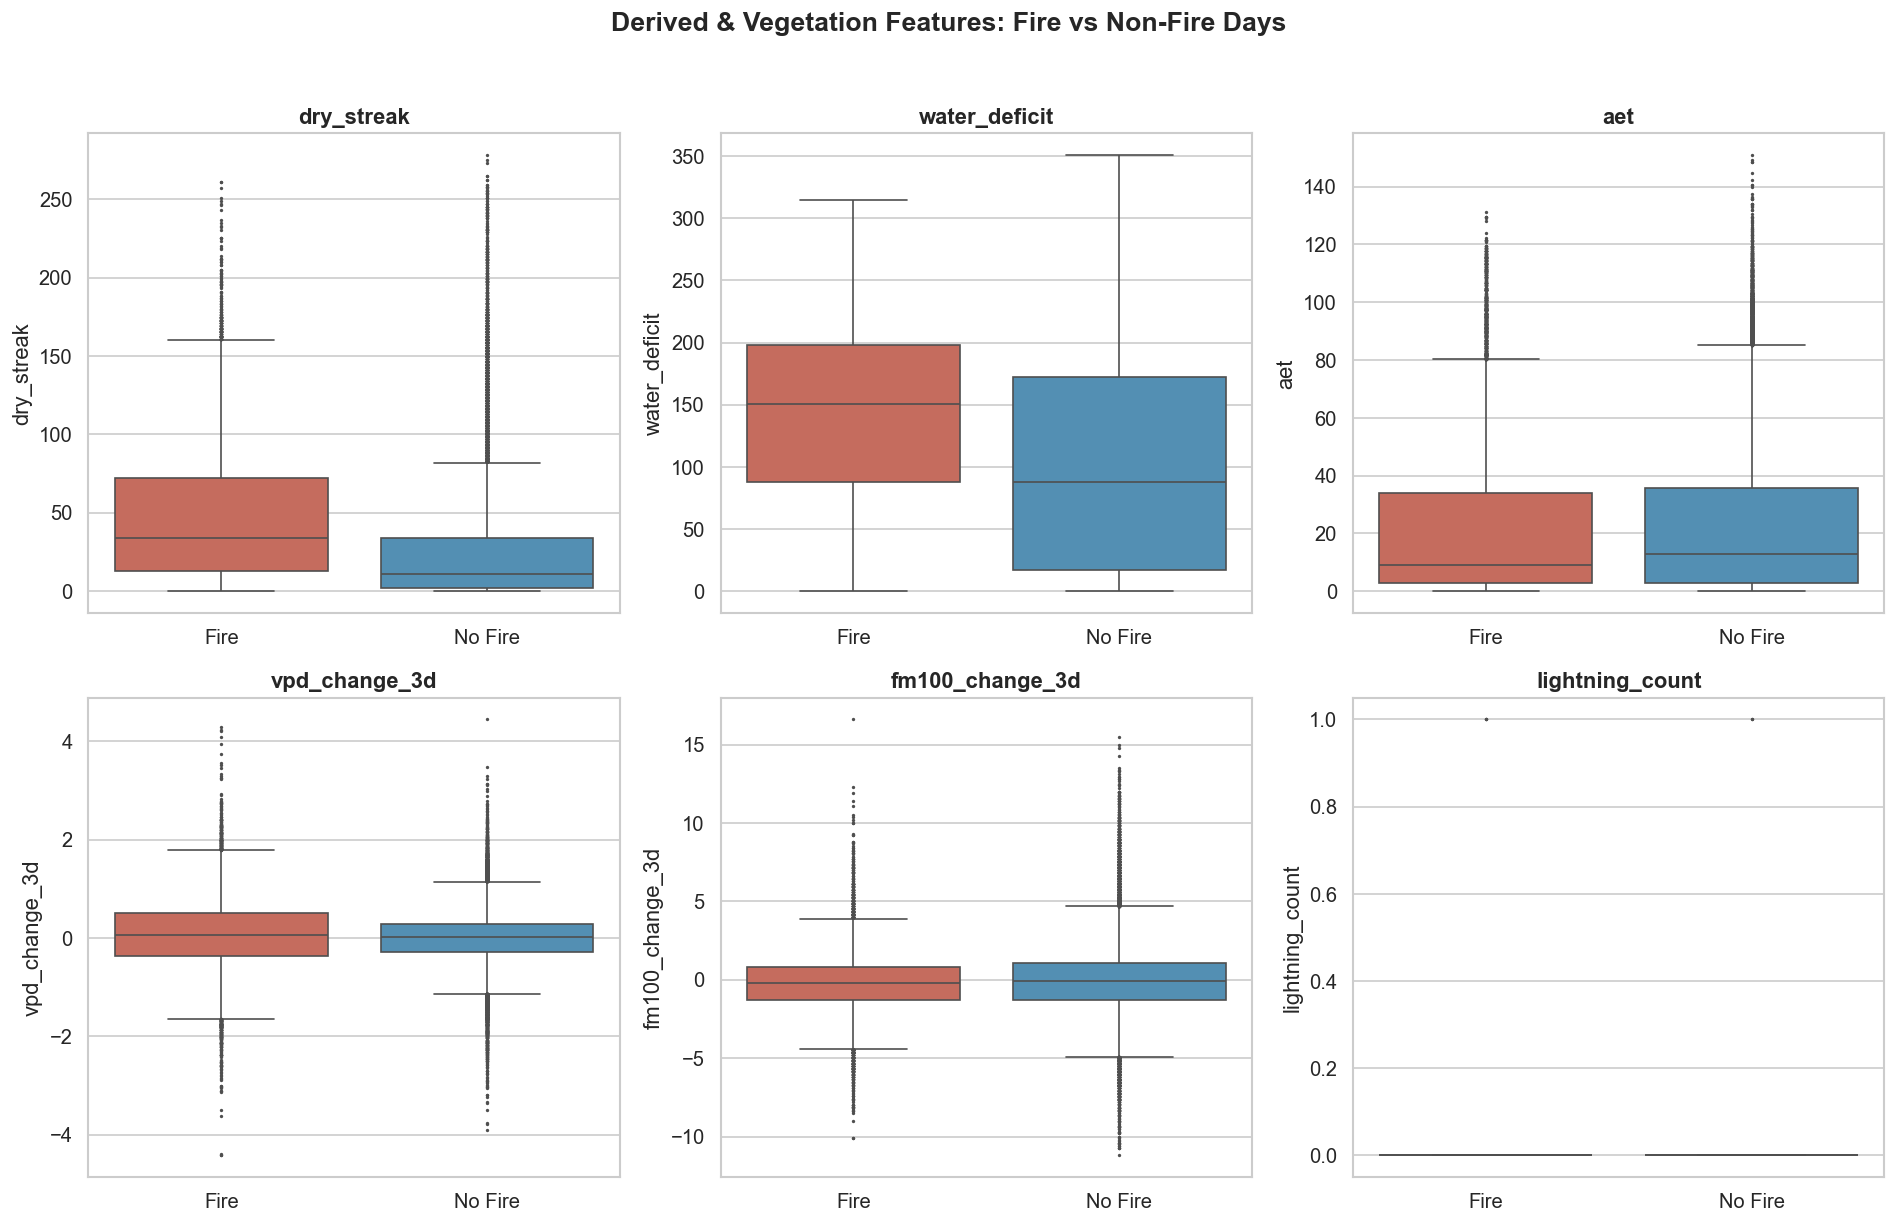

In [6]:
derived_features = ['dry_streak', 'water_deficit', 'aet', 'vpd_change_3d', 'fm100_change_3d', 'lightning_count']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, col in zip(axes.ravel(), derived_features):
    sns.boxplot(data=plot_df, x='Fire', y=col, ax=ax,
                palette={'No Fire': '#4393c3', 'Fire': '#d6604d'},
                fliersize=1)
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('')
fig.suptitle('Derived & Vegetation Features: Fire vs Non-Fire Days', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../notebooks/plots/04_fire_vs_nofire_derived.png', bbox_inches='tight')
plt.show()

**Takeaways:**
- **tmmx_c**: Clearest separation — fire-day median ~28°C vs non-fire ~21°C.
- **vpd, fm100, rmin**: Consistent shifts — drier air and drier fuels on fire days.
- **pr**: Nearly zero precipitation on fire days. Rain effectively prevents fires.
- **dry_streak**: Strong separation — fire days have much longer dry streaks (median ~45 vs ~25 days).
- **water_deficit**: Higher on fire days — vegetation is drier and acts as fuel.
- **vs (wind)**: Minimal difference — wind alone doesn't predict fires.
- **lightning_count**: Nearly all zeros in both classes — too rare for box plots, but individual events can still trigger fires.

---
## 4. Fire Rate by Feature Bins
Correlation and box plots show averages, but not the *shape* of the relationship. Here we split each feature into 10 equal-sized bins and plot the fire rate per bin. This reveals whether the relationship is linear, has a threshold, or is U-shaped.

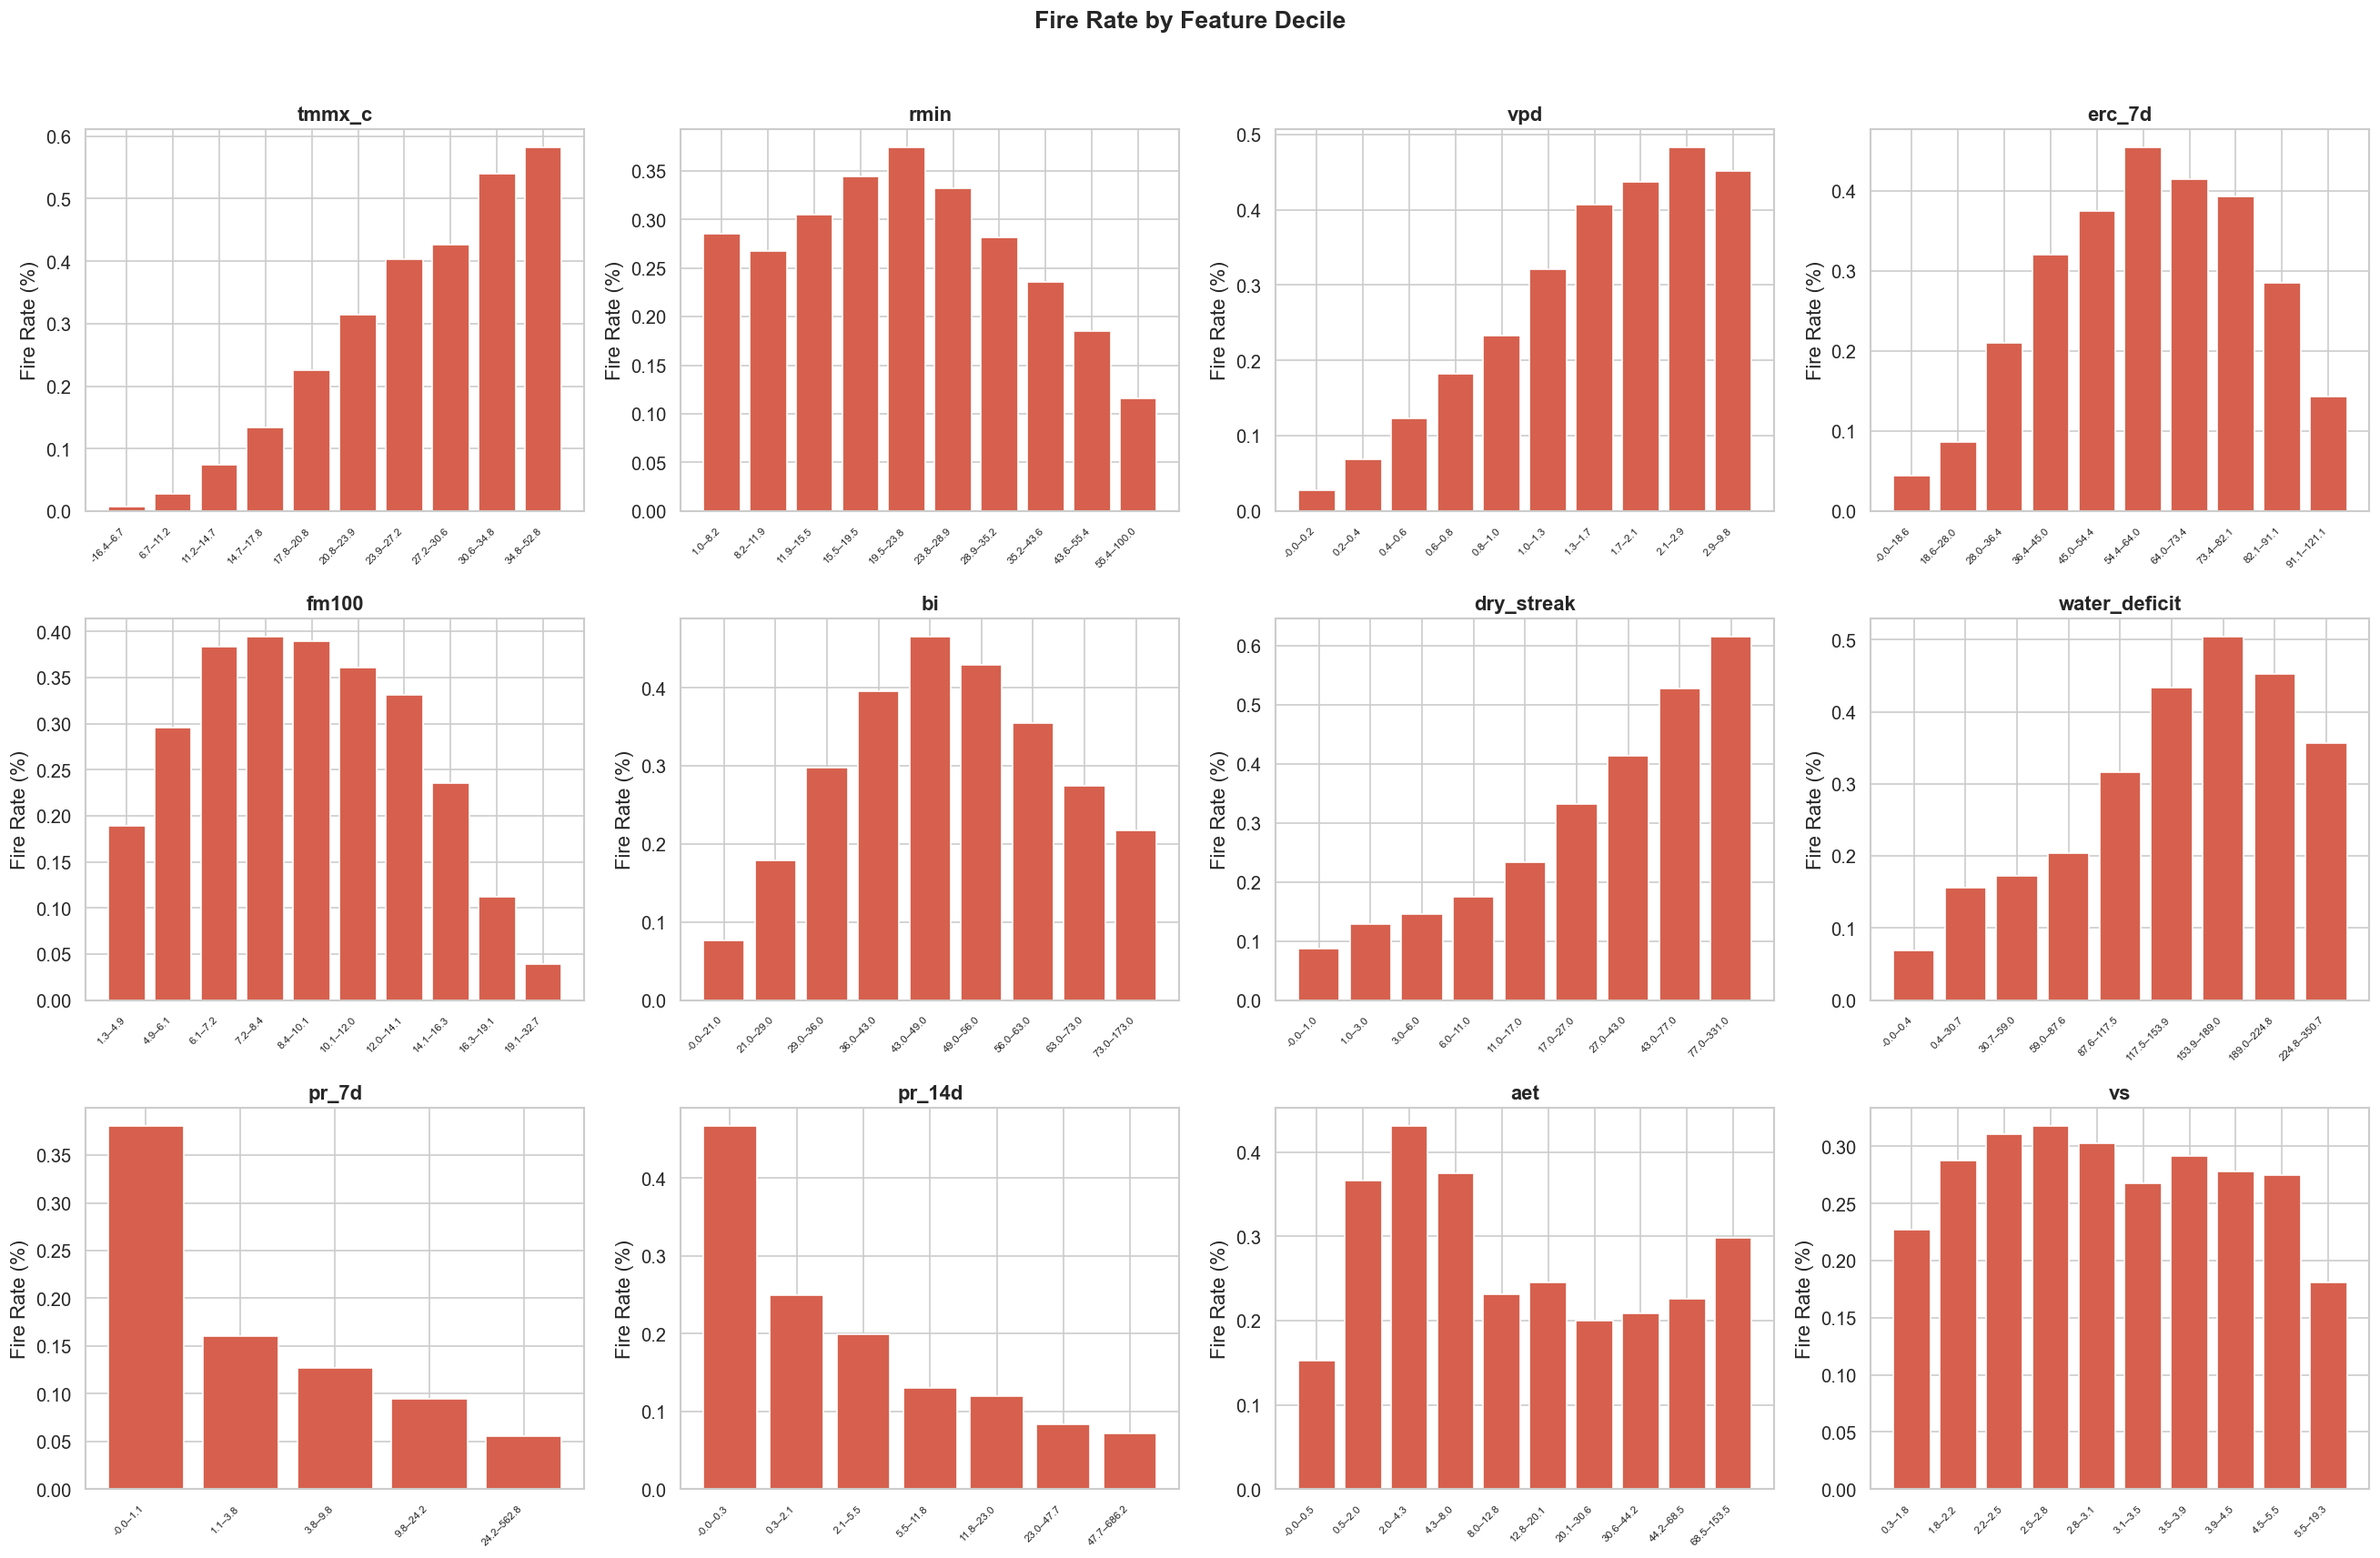

In [7]:
def plot_fire_rate_by_bins(df, col, n_bins=10, ax=None):
    df_tmp = df[[col, 'has_fire']].dropna()
    df_tmp['bin'] = pd.qcut(df_tmp[col], q=n_bins, duplicates='drop')
    rates = df_tmp.groupby('bin', observed=True)['has_fire'].agg(['mean', 'count'])
    rates['mean'] *= 100
    if ax is None:
        fig, ax = plt.subplots()
    ax.bar(range(len(rates)), rates['mean'], color='#d6604d', edgecolor='white')
    ax.set_xticks(range(len(rates)))
    labels = [f'{interval.left:.1f}–{interval.right:.1f}' for interval in rates.index]
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=7)
    ax.set_ylabel('Fire Rate (%)')
    ax.set_title(col, fontweight='bold')
    return ax

key_features = ['tmmx_c', 'rmin', 'vpd', 'erc_7d', 'fm100', 'bi', 'dry_streak', 'water_deficit',
                'pr_7d', 'pr_14d', 'aet', 'vs']

fig, axes = plt.subplots(3, 4, figsize=(22, 14))
for ax, col in zip(axes.ravel(), key_features):
    plot_fire_rate_by_bins(df, col, n_bins=10, ax=ax)
fig.suptitle('Fire Rate by Feature Decile', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../notebooks/plots/05_fire_rate_by_bins.png', bbox_inches='tight')
plt.show()

**Takeaways:**
- **tmmx_c, vpd, dry_streak, water_deficit**: Near-linear ramps — fire rate climbs steadily as conditions get hotter/drier.
- **fm100**: Inverse — lower fuel moisture = higher fire rate.
- **pr_7d, pr_14d**: Inverse — more recent rain = fewer fires. Lowest bin (no rain) has ~0.35% fire rate vs ~0.05% for the wettest.
- **vs (wind)**: Slight U-shape — both calm and very windy days have slightly elevated rates.
- **aet**: Mostly flat — evapotranspiration alone is a weak predictor.

---
## 5. Temporal Patterns
When do fires happen? Three views: monthly fire rate (seasonality), daily fire counts (event-level spikes), and annual totals.

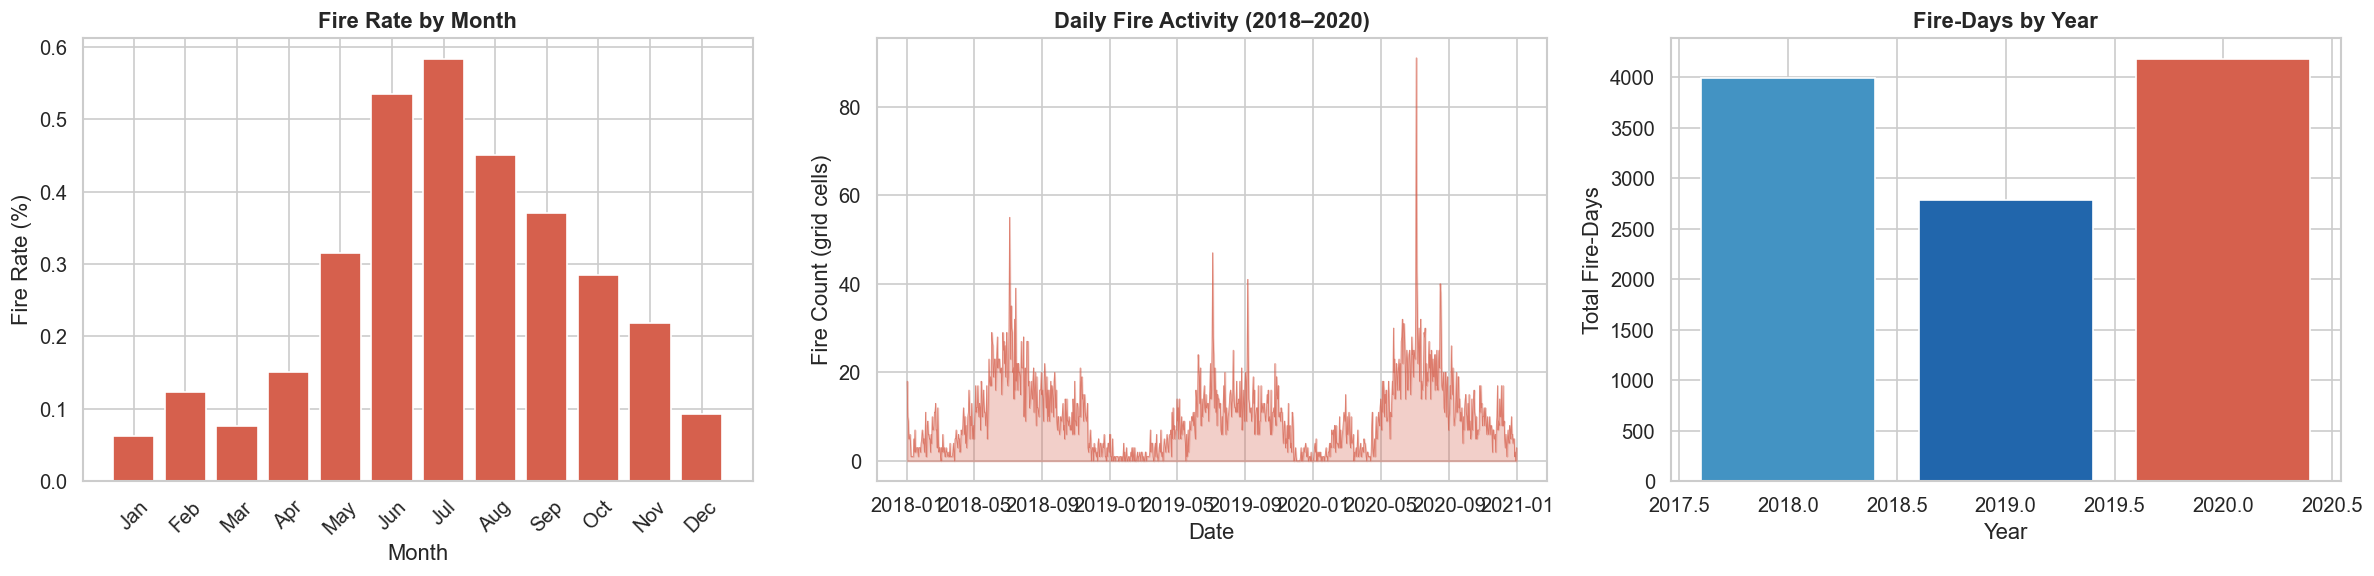

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

monthly = df.groupby('month')['has_fire'].mean() * 100
axes[0].bar(monthly.index, monthly.values, color='#d6604d', edgecolor='white')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Fire Rate (%)')
axes[0].set_title('Fire Rate by Month', fontweight='bold')
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], rotation=45)

daily_fires = df.groupby('date')['has_fire'].sum()
axes[1].plot(daily_fires.index, daily_fires.values, color='#d6604d', alpha=0.7, linewidth=0.5)
axes[1].fill_between(daily_fires.index, daily_fires.values, alpha=0.3, color='#d6604d')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Fire Count (grid cells)')
axes[1].set_title('Daily Fire Activity (2018–2020)', fontweight='bold')

df['year'] = df['date'].dt.year
yearly = df.groupby('year')['has_fire'].sum()
axes[2].bar(yearly.index, yearly.values, color=['#4393c3', '#2166ac', '#d6604d'], edgecolor='white')
axes[2].set_xlabel('Year')
axes[2].set_ylabel('Total Fire-Days')
axes[2].set_title('Fire-Days by Year', fontweight='bold')

plt.tight_layout()
plt.savefig('../notebooks/plots/06_temporal_patterns.png', bbox_inches='tight')
plt.show()

**Takeaways:**
- **Seasonality**: Fire season peaks June–July (~0.55%), drops to ~0.06% in winter. The ramp starts in April.
- **Daily spikes**: Sharp peaks correspond to major fire events. 2020 has the most intense spikes (August Complex, Creek, Glass fires).
- **2020** had the most fire-days — California's worst fire season on record. 2019 was the quietest.

---
## 6. Geographic Fire Distribution
Where do fires cluster? Each grid cell is a dot, colored by total fire-days. The left map shows all cells; the right map highlights only fire-active cells.

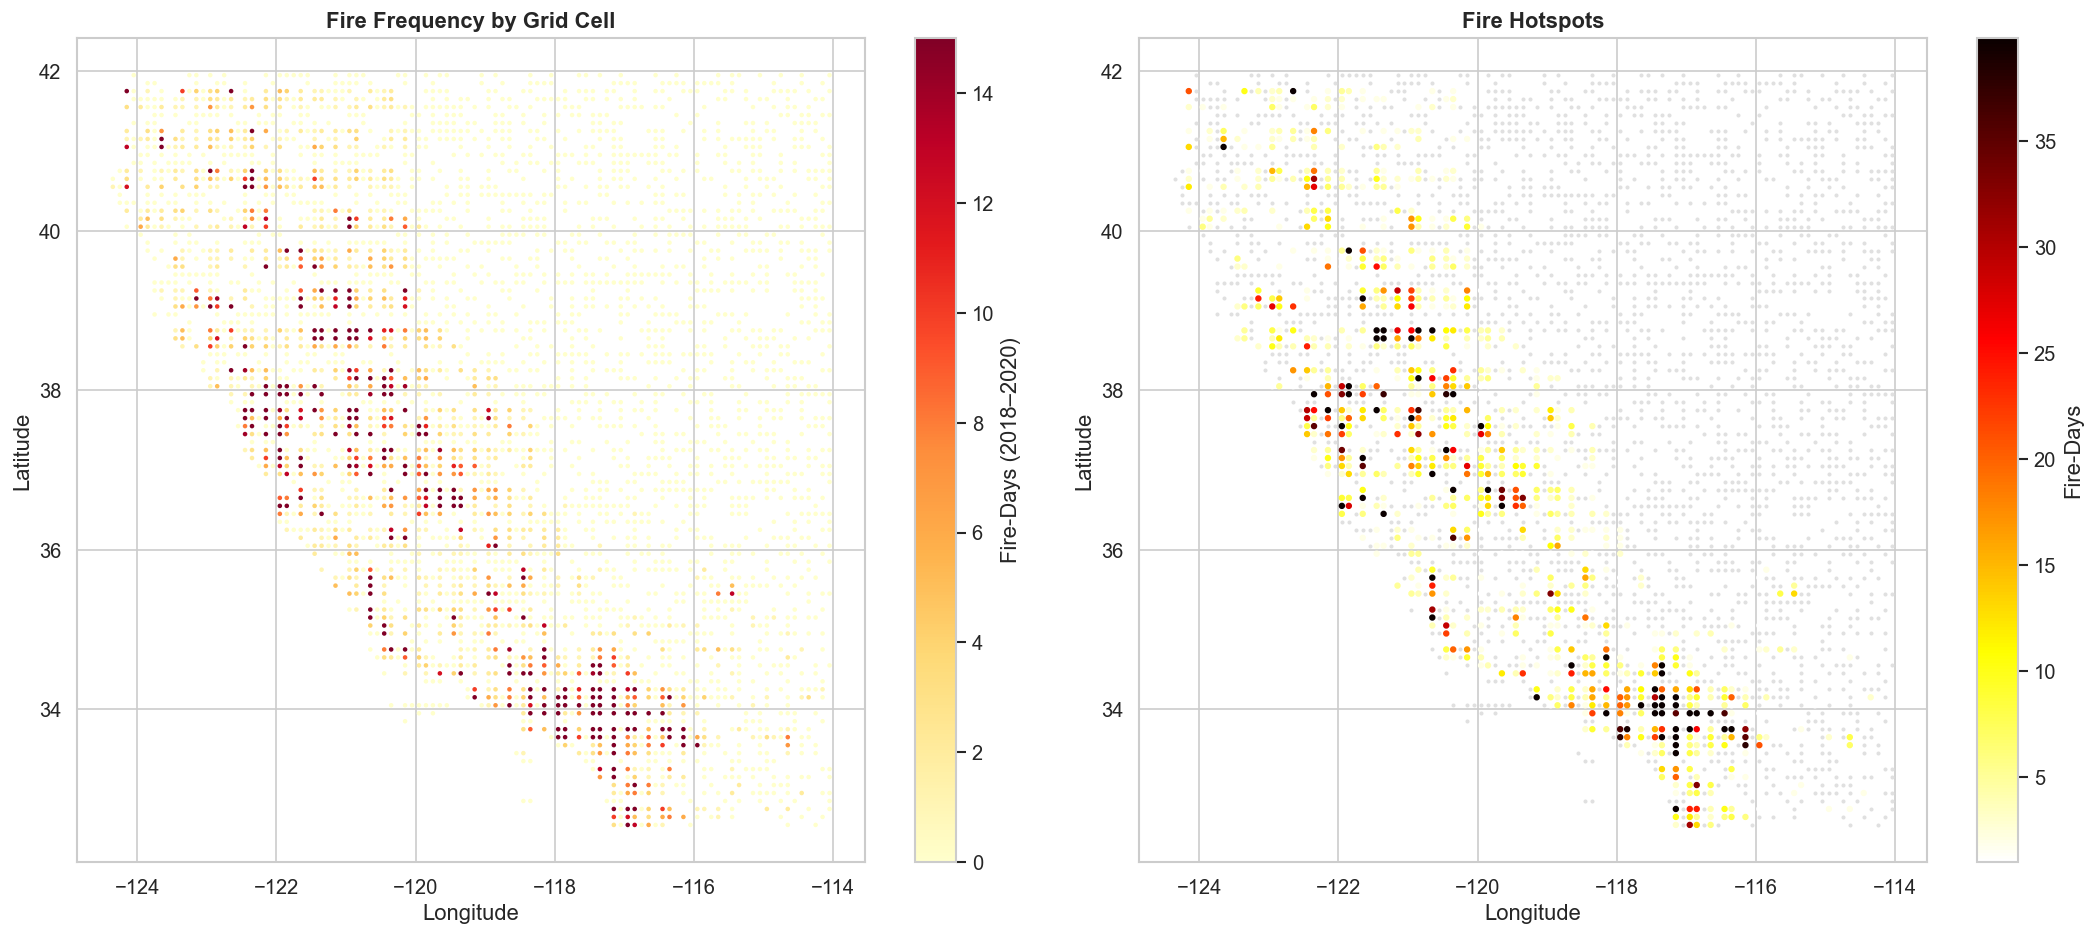

In [9]:
cell_fires = df.groupby('grid_id').agg(
    fire_days=('has_fire', 'sum'),
    lat=('lat_center', 'first'),
    lon=('lon_center', 'first')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

sc = axes[0].scatter(cell_fires['lon'], cell_fires['lat'], 
                     c=cell_fires['fire_days'], cmap='YlOrRd', s=3, 
                     vmin=0, vmax=cell_fires['fire_days'].quantile(0.95))
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
axes[0].set_title('Fire Frequency by Grid Cell', fontweight='bold')
plt.colorbar(sc, ax=axes[0], label='Fire-Days (2018–2020)')

fire_cells = cell_fires[cell_fires['fire_days'] > 0]
no_fire_cells = cell_fires[cell_fires['fire_days'] == 0]
axes[1].scatter(no_fire_cells['lon'], no_fire_cells['lat'], c='#e0e0e0', s=2, label='No fires')
sc2 = axes[1].scatter(fire_cells['lon'], fire_cells['lat'],
                      c=fire_cells['fire_days'], cmap='hot_r', s=8,
                      vmin=1, vmax=fire_cells['fire_days'].quantile(0.95))
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')
axes[1].set_title('Fire Hotspots', fontweight='bold')
plt.colorbar(sc2, ax=axes[1], label='Fire-Days')

plt.tight_layout()
plt.savefig('../notebooks/plots/07_geographic_fire_map.png', bbox_inches='tight')
plt.show()

**Takeaways:**
- **SoCal mountains** (lat ~34°, LA / San Bernardino) are the biggest hotspot.
- **Sierra Nevada foothills** (lat ~37–39°) show another fire concentration.
- **NorCal forests** (lat ~40–41°) had major 2020 mega-fire activity.
- **Central Valley** (flat agricultural land) has almost no fires — irrigated farmland doesn't burn.
- **Eastern desert** has scattered fires but low density — less vegetation to fuel them.

---
## 7. Feature Redundancy Analysis
Many features move together (as the heatmap showed). Here we list all pairs with |r| > 0.85 to quantify the redundancy and decide what to drop.

In [10]:
corr_matrix = df[feature_cols].corr()
high_corr_pairs = []
for i in range(len(feature_cols)):
    for j in range(i + 1, len(feature_cols)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.85:
            high_corr_pairs.append({
                'Feature A': feature_cols[i],
                'Feature B': feature_cols[j],
                'Correlation': r,
                'Corr with Fire (A)': df[feature_cols[i]].corr(df['has_fire']),
                'Corr with Fire (B)': df[feature_cols[j]].corr(df['has_fire']),
            })

redundancy = pd.DataFrame(high_corr_pairs).sort_values('Correlation', key=abs, ascending=False)
print(f'Found {len(redundancy)} feature pairs with |r| > 0.85:\n')
print(redundancy.to_string(index=False))

Found 23 feature pairs with |r| > 0.85:

    Feature A Feature B  Correlation  Corr with Fire (A)  Corr with Fire (B)
       erc_7d   erc_14d     0.985417            0.011415            0.010105
       vpd_7d   vpd_14d     0.979923            0.022776            0.022065
        bi_7d    bi_14d     0.964692            0.014102            0.013246
       erc_7d    bi_14d     0.958885            0.011415            0.013246
      erc_14d    bi_14d     0.957597            0.010105            0.013246
       erc_7d     bi_7d     0.945289            0.011415            0.014102
       tmmx_c   tmmx_7d     0.942655            0.037138            0.036948
          vpd    vpd_7d     0.933377            0.024725            0.022776
          vpd   vpd_14d     0.915181            0.024725            0.022065
      erc_14d     bi_7d     0.909051            0.010105            0.014102
       vpd_7d   tmmx_7d     0.905434            0.022776            0.036948
        fm100   rmin_7d     0.90437

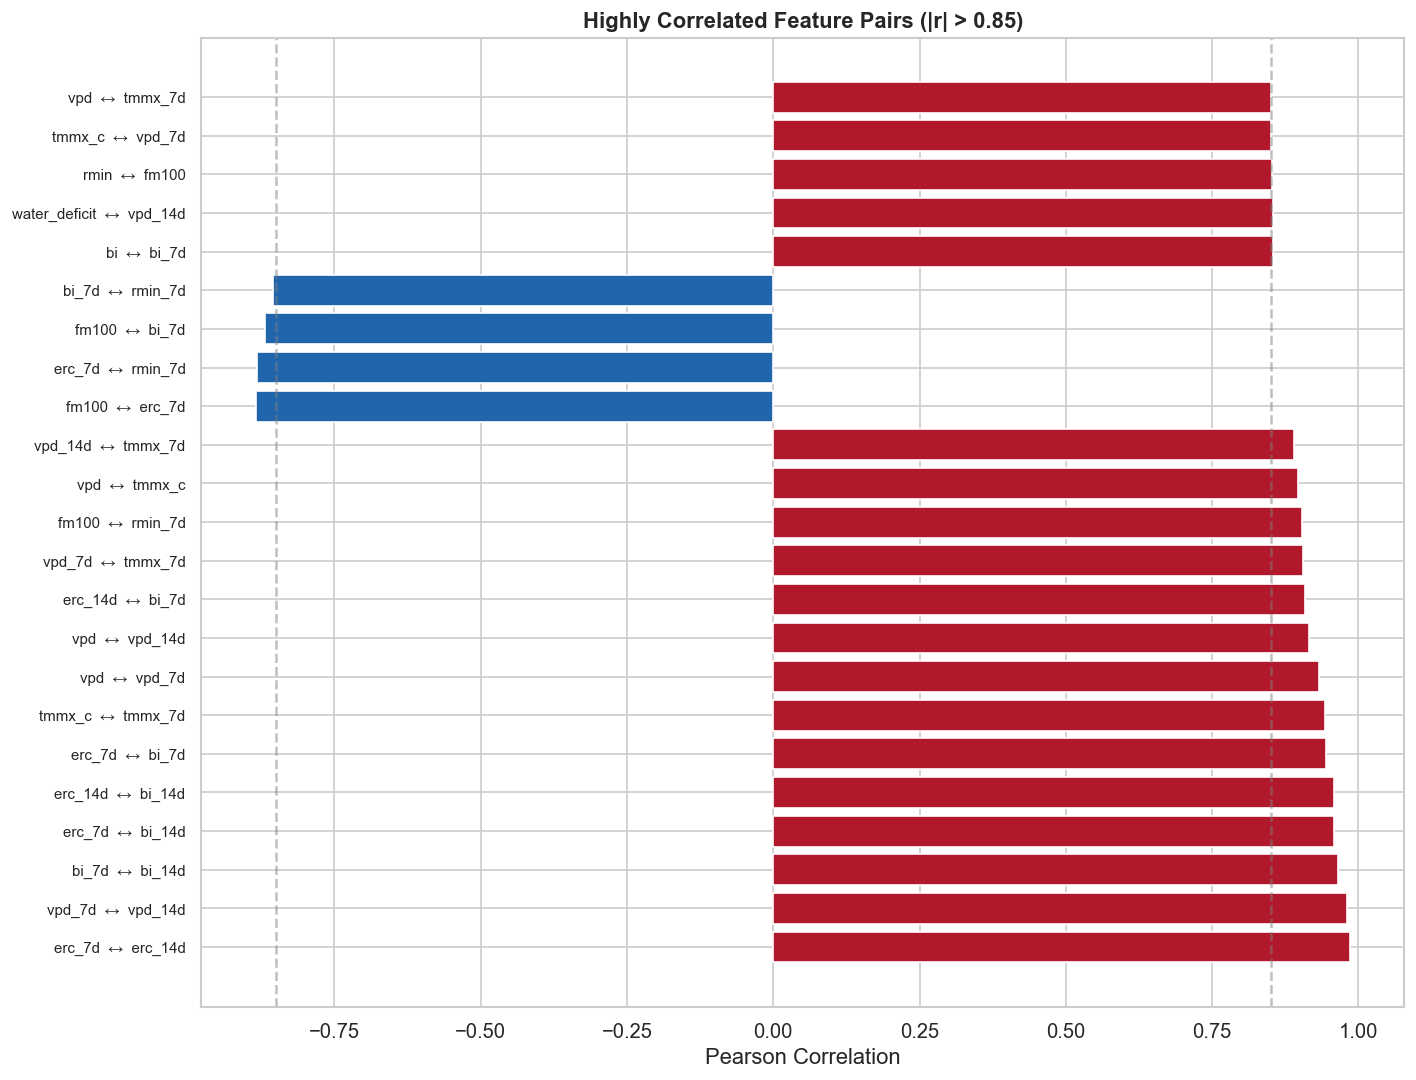

In [11]:
if len(redundancy) > 0:
    fig, ax = plt.subplots(figsize=(12, max(4, len(redundancy) * 0.4)))
    y_pos = range(len(redundancy))
    colors = ['#b2182b' if r > 0 else '#2166ac' for r in redundancy['Correlation']]
    ax.barh(y_pos, redundancy['Correlation'].values, color=colors, edgecolor='white')
    labels = [f"{row['Feature A']}  ↔  {row['Feature B']}" for _, row in redundancy.iterrows()]
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlabel('Pearson Correlation')
    ax.set_title('Highly Correlated Feature Pairs (|r| > 0.85)', fontweight='bold')
    ax.axvline(x=0.85, color='gray', linestyle='--', alpha=0.5)
    ax.axvline(x=-0.85, color='gray', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig('../notebooks/plots/08_redundant_pairs.png', bbox_inches='tight')
    plt.show()

**Takeaways:**
- Most high correlations are between rolling averages of the same variable (e.g., `erc_7d ↔ erc_14d` at r=0.99). We keep these — they may capture different time-scale patterns.
- `fm100 ↔ erc_7d` (r=-0.88): fuel moisture and fire danger are inversely linked — physically logical.
- `vpd ↔ tmmx_c` (r=0.90): vapor pressure deficit is largely driven by temperature.

---
## 8. Scatter Plots — Key Feature Pairs
Do fire events cluster in specific regions of the feature space? Scatter plots of top predictor pairs, with fire days (red) overlaid on non-fire days (blue).

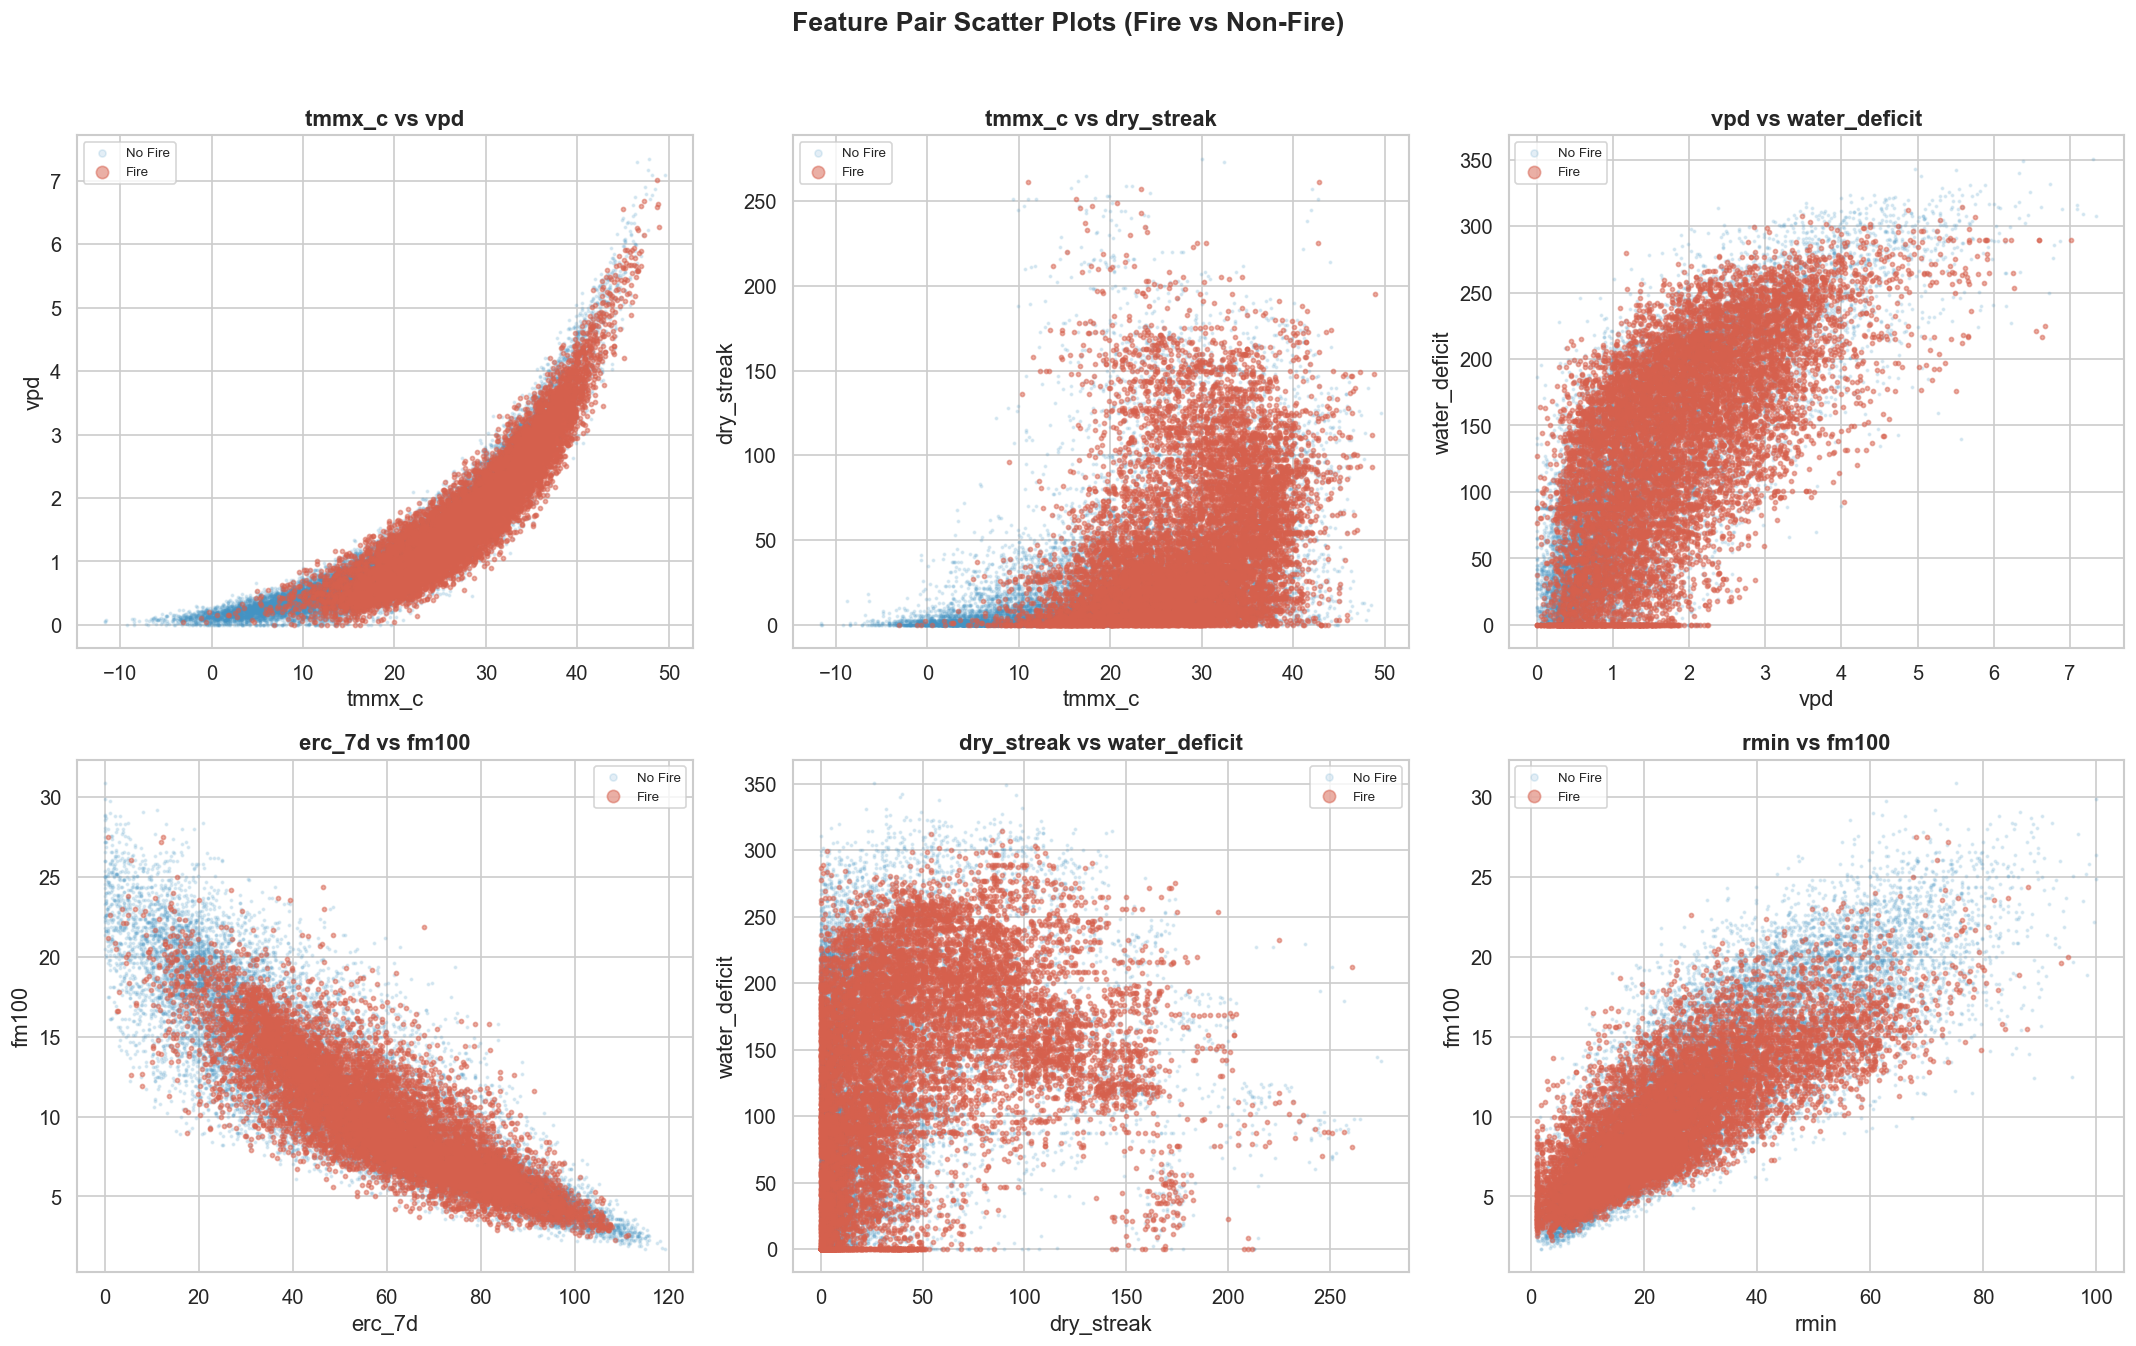

In [12]:
scatter_df = pd.concat([
    df[df['has_fire'] == 1],
    df[df['has_fire'] == 0].sample(n=20000, random_state=42)
])

pairs = [
    ('tmmx_c', 'vpd'),
    ('tmmx_c', 'dry_streak'),
    ('vpd', 'water_deficit'),
    ('erc_7d', 'fm100'),
    ('dry_streak', 'water_deficit'),
    ('rmin', 'fm100'),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
for ax, (x, y) in zip(axes.ravel(), pairs):
    nofire = scatter_df[scatter_df['has_fire'] == 0]
    fire = scatter_df[scatter_df['has_fire'] == 1]
    ax.scatter(nofire[x], nofire[y], c='#4393c3', s=2, alpha=0.15, label='No Fire')
    ax.scatter(fire[x], fire[y], c='#d6604d', s=6, alpha=0.5, label='Fire')
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(f'{x} vs {y}', fontweight='bold')
    ax.legend(fontsize=8, markerscale=3)

fig.suptitle('Feature Pair Scatter Plots (Fire vs Non-Fire)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../notebooks/plots/09_scatter_pairs.png', bbox_inches='tight')
plt.show()

**Takeaways:**
- **tmmx_c vs vpd**: Fires cluster in the upper-right — high temperature + high VPD. Very few fires in the cool/humid lower-left.
- **tmmx_c vs dry_streak**: Fires concentrate at high temp AND long dry streaks. The combination is more dangerous than either alone.
- **vpd vs water_deficit**: Fires cluster when both air and vegetation are dry.
- **erc_7d vs fm100**: Fires cluster at high ERC / low fuel moisture (upper-left).
- **dry_streak vs water_deficit**: Prolonged drought + dry vegetation = highest-risk scenario.

---
## 9. Leading Indicators — Feature Behavior Around Fire Events
The most important question for prediction: do features change *before* a fire starts? We average each feature over the 30 days before and after 200 sampled fire events. Features that ramp before day 0 are leading indicators.

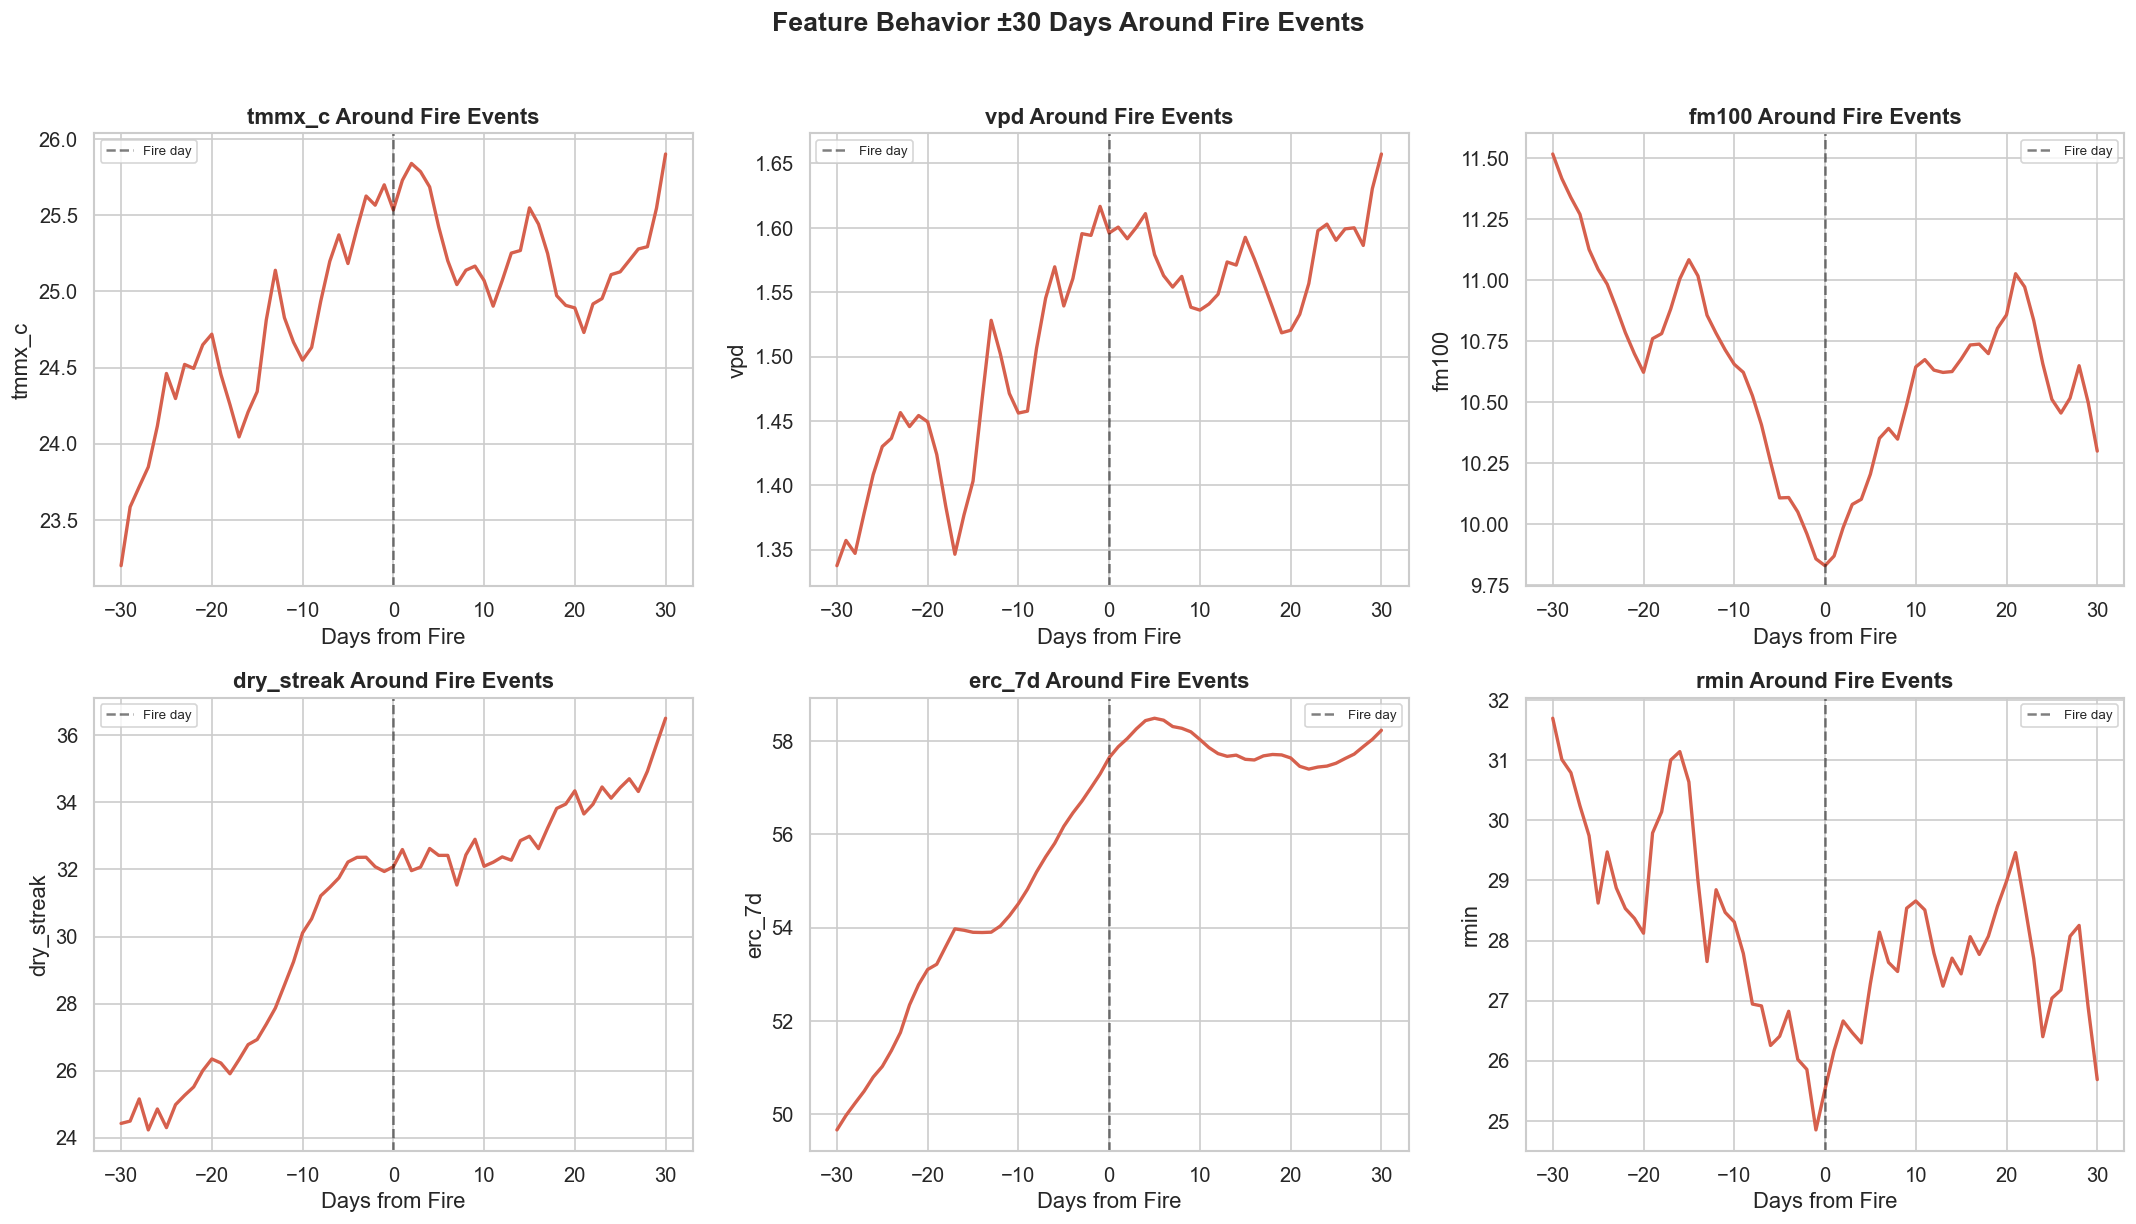

In [13]:
fire_events = df[df['has_fire'] == 1].groupby('grid_id')['date'].first().reset_index()
fire_events.columns = ['grid_id', 'fire_date']
sample_events = fire_events.sample(n=min(200, len(fire_events)), random_state=42)

windows = []
for _, row in sample_events.iterrows():
    cell_data = df[df['grid_id'] == row['grid_id']].copy()
    cell_data['days_from_fire'] = (cell_data['date'] - row['fire_date']).dt.days
    window = cell_data[(cell_data['days_from_fire'] >= -30) & (cell_data['days_from_fire'] <= 30)]
    windows.append(window)

window_df = pd.concat(windows)

lead_features = ['tmmx_c', 'vpd', 'fm100', 'dry_streak', 'erc_7d', 'rmin']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, col in zip(axes.ravel(), lead_features):
    avg = window_df.groupby('days_from_fire')[col].mean()
    ax.plot(avg.index, avg.values, color='#d6604d', linewidth=2)
    ax.axvline(x=0, color='black', linestyle='--', alpha=0.5, label='Fire day')
    ax.set_xlabel('Days from Fire')
    ax.set_ylabel(col)
    ax.set_title(f'{col} Around Fire Events', fontweight='bold')
    ax.legend(fontsize=8)

fig.suptitle('Feature Behavior ±30 Days Around Fire Events', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../notebooks/plots/10_leading_indicators.png', bbox_inches='tight')
plt.show()

**Takeaways:**
- **tmmx_c, vpd, erc_7d**: Rise steadily 2–3 weeks before fire, peak around day 0, then drop. Temperature and dryness buildup is a genuine leading signal.
- **fm100, rmin**: Drop before fires — fuel and air get drier in the lead-up. Sharp recovery after (rain or season change).
- **dry_streak**: Climbs steadily — each rainless day adds to the streak.
- **Key implication**: Features carry predictive signal *days before* a fire. The model has real information for early warning, not just same-day detection.

---
## 10. 2nd Round Cleaning — Redundancy Removal
Based on this analysis, we drop 4 features that are **duplicate encodings** of the same information. Rolling averages are kept — even though correlated with daily values, they capture sustained conditions that may improve model performance.

**Dropped:** `day_of_year` (= `month`, r=0.997), `doy_sin` (= `month_sin`, r=0.955), `month_cos` (= `doy_cos`, r=0.955), `erc` (= `bi_7d`, r=0.936 — burning index is the better version).

In [14]:
dropped = ['day_of_year', 'doy_sin', 'month_cos', 'erc']
remaining = [c for c in feature_cols if c not in dropped]

print('DROPPED (duplicate encodings):')
for c in dropped:
    print(f'  ✗ {c}')

print(f'\nKEEPING ({len(remaining)} features):')
for c in sorted(remaining):
    fire_r = df[c].corr(df['has_fire'])
    print(f'  {c:>20s}  (fire corr: {fire_r:+.4f})')

DROPPED (duplicate encodings):
  ✗ day_of_year
  ✗ doy_sin
  ✗ month_cos
  ✗ erc

KEEPING (28 features):
                   aet  (fire corr: -0.0022)
                    bi  (fire corr: +0.0134)
                bi_14d  (fire corr: +0.0132)
                 bi_7d  (fire corr: +0.0141)
               doy_cos  (fire corr: -0.0293)
            dry_streak  (fire corr: +0.0273)
               erc_14d  (fire corr: +0.0101)
                erc_7d  (fire corr: +0.0114)
                 fm100  (fire corr: -0.0145)


       fm100_change_3d  (fire corr: -0.0051)
            lat_center  (fire corr: -0.0273)
       lightning_count  (fire corr: +0.0012)
            lon_center  (fire corr: -0.0221)
                 month  (fire corr: +0.0096)
             month_sin  (fire corr: -0.0205)
                    pr  (fire corr: -0.0086)
                pr_14d  (fire corr: -0.0172)
                 pr_7d  (fire corr: -0.0153)
                  rmin  (fire corr: -0.0115)


               rmin_7d  (fire corr: -0.0091)
               tmmx_7d  (fire corr: +0.0369)
                tmmx_c  (fire corr: +0.0371)
                   vpd  (fire corr: +0.0247)
               vpd_14d  (fire corr: +0.0221)
                vpd_7d  (fire corr: +0.0228)
         vpd_change_3d  (fire corr: +0.0064)
                    vs  (fire corr: -0.0042)
         water_deficit  (fire corr: +0.0244)


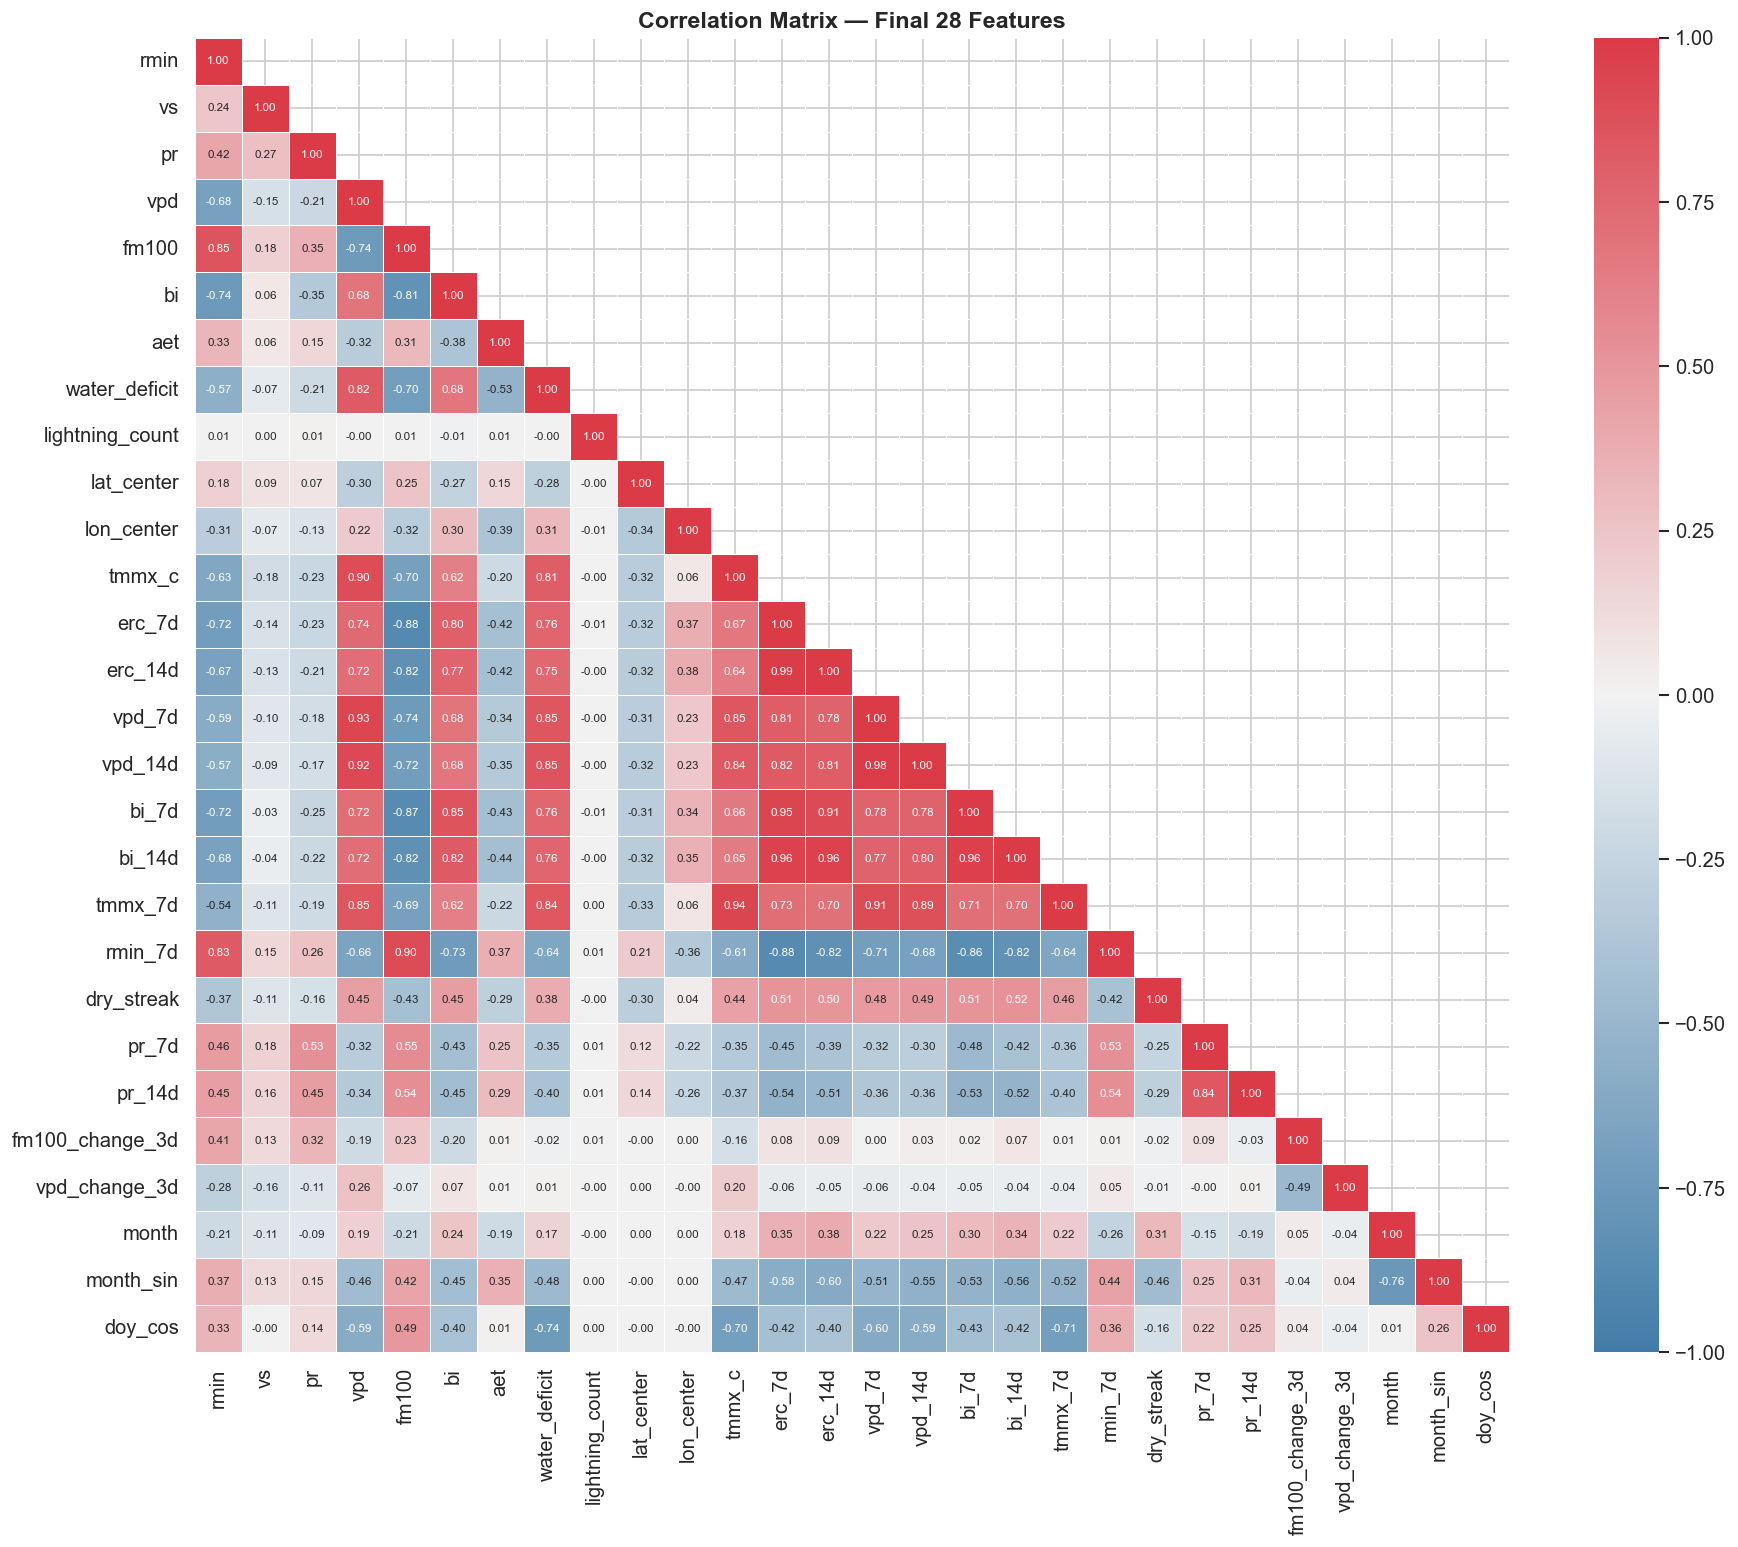


Highest remaining correlation: erc_7d ↔ erc_14d = 0.985


In [15]:
remaining_corr = df[remaining].corr()

fig, ax = plt.subplots(figsize=(16, 13))
mask = np.triu(np.ones_like(remaining_corr, dtype=bool), k=1)
sns.heatmap(remaining_corr, mask=mask, cmap=cmap, center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', annot_kws={'size': 7},
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix — Final 28 Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../notebooks/plots/11_correlation_after_cleaning.png', bbox_inches='tight')
plt.show()

remaining_pairs = remaining_corr.where(~np.eye(len(remaining), dtype=bool)).stack()
max_pair = remaining_pairs.abs().idxmax()
print(f'\nHighest remaining correlation: {max_pair[0]} ↔ {max_pair[1]} = {remaining_pairs[max_pair]:.3f}')